In [1]:
import glob
import os
import tqdm
import math

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
# import mpl_toolkits.axes_grid1
import japanize_matplotlib

import astropy
import astropy.io.fits
import astropy.units as u
import astroquery.vizier
from astropy.coordinates import SkyCoord
# from astropy.wcs import WCS
from spectral_cube import SpectralCube
import pylab

pylab.rcParams['font.family'] = 'serif'
pylab.rcParams['lines.linewidth'] = 0.5
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.size"] = 15
pylab.rcParams["xtick.direction"] = "in"
pylab.rcParams["ytick.direction"] = "in"

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Meirio', 'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 'Noto Sans CJK JP']

In [2]:
import sys
# sys.path.append('/home/elmegreen/galactic_bubble/photoutils/')
from processing import norm_res, normalize_rp, remove_nan, conv, data_view_rectangl, resize
from utils.ssd_model import nm_suppression

# sys.path.append('/home/elmegreen/jupyter/research/Bubble_Analysis/CO_SpitzerBubble/All_Bubble_Analysis/Analysis')
from Function_to_Detect_peak import find_verified_peak, _detect_and_characterize_peak, find_velocity_from_catalog, _check_signal_at_channel, gaussian_filter
from detect_rough_tools import extract_spectral, make_spitzer_fits, load_spitzer_fits, make_momont012_map

In [3]:
viz = astroquery.vizier.Vizier(columns=["*"])
viz.ROW_LIMIT = -1
MWP = viz.query_constraints(catalog="2019yCat..74881141J ")[0].to_pandas()

# ⬇️バブルの中に銀河中心を跨ぐものがあった場合、座標がバグる((359.9, 0.01)みたいに。それを(-0.01, 0.01)に変換して防ぐ)
MWP.loc[MWP["GLON"] >= 358.446500015535, "GLON"] -= 360
MWP.index = MWP['MWP'].to_list()

In [4]:
MWP

,MWP,GLON,GLAT,Disp,MajAxis,MinAxis,Reff,e_Reff,theta,e_theta,...,HR3,RelFlag,HierFlag,IDDR1,IDA14,Dist,IDCW,Simbad,_RA.icrs,_DE.icrs
2G0000794-0020817,2G0000794-0020817,0.0794,-0.2082,0.22,0.58,0.49,0.53,0.13,161,133,...,0.18,R,,1G000080-002075,G000.079-00.211,NaN,CN2,Simbad,266.6554,-28.9766
2G0001255+0003035,2G0001255+0003035,0.1255,0.0303,1.01,5.05,4.26,4.67,0.59,87,62,...,0.20,C,,1G000127+000485,G000.132+00.039,NaN,,Simbad,266.4501,-28.8133
2G0001301-0067518,2G0001301-0067518,0.1301,-0.6752,0.20,0.45,0.37,0.41,0.12,24,122,...,0.42,R,,,G000.129-00.674,NaN,CN4,Simbad,267.1427,-29.1749
2G0001400-0011719,2G0001400-0011719,0.1400,-0.1172,0.29,3.14,2.98,3.06,0.37,11,86,...,0.46,C,,1G000140-001173,G000.138-00.115,NaN,,Simbad,266.6025,-28.8776
2G0002791-0048490,2G0002791-0048490,0.2791,-0.4849,0.12,0.42,0.38,0.40,0.23,34,94,...,0.08,R,,,G000.279-00.482,NaN,CN7,Simbad,267.0442,-28.9491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2G3593514-0041492,2G3593514-0041492,-0.6486,-0.4149,0.34,0.44,0.35,0.40,0.24,52,83,...,0.08,C,,1G359350-004141,G359.349-00.417,NaN,,Simbad,266.4237,-29.7059
2G3596901+0006590,2G3596901+0006590,-0.3099,0.0659,0.10,0.59,0.51,0.55,0.06,77,79,...,0.13,C,,,G359.690+00.065,NaN,,Simbad,266.1557,-29.1661
2G3597425-0041121,2G3597425-0041121,-0.2575,-0.4112,0.94,1.97,1.82,1.90,0.68,27,106,...,0.44,R,,1G359737-004097,G359.740-00.412,NaN,CS2,Simbad,266.6538,-29.3700
2G3599224+0011336,2G3599224+0011336,-0.0776,0.1134,0.28,1.08,0.93,1.00,0.31,103,64,...,0.24,C,,,G359.930+00.108,NaN,,Simbad,266.2482,-28.9432


In [5]:
MWP.columns

Index(['MWP', 'GLON', 'GLAT', 'Disp', 'MajAxis', 'MinAxis', 'Reff', 'e_Reff',
       'theta', 'e_theta', 'Ecc', 'HR2', 'HR3', 'RelFlag', 'HierFlag', 'IDDR1',
       'IDA14', 'Dist', 'IDCW', 'Simbad', '_RA.icrs', '_DE.icrs'],
      dtype='object')

In [6]:
viz = astroquery.vizier.Vizier(columns=["*"])
viz.ROW_LIMIT = -1
bub_velocity_table = viz.query_constraints(catalog="J/MNRAS/438/426")[0].to_pandas()

# GLONを0-360度の範囲に正規化
bub_velocity_table['GLON'] = bub_velocity_table['GLON'] % 360
bub_velocity_table['GLON2'] = bub_velocity_table['GLON2'] % 360

print(f"読み込んだバブル速度カタログのエントリ数: {len(bub_velocity_table)}")
print("カタログの列名:", bub_velocity_table.columns.tolist())

読み込んだバブル速度カタログのエントリ数: 818
カタログの列名: ['MWP', 'GLON', 'GLAT', 'Reff', 'GLON2', 'GLAT2', 'Ref', 'VHII', 'D0', 'e_D0', 'r_D0', 'DK', 'e_DK', 'Mark', 'r_Mark', 'Simbad', '_RA.icrs', '_DE.icrs']


In [7]:
cygnus_bubble_catalogue = pd.read_csv('/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_Catalogue/cygnus_infer_catalogue.csv')
cygnus_bubble_catalogue['ra_center'] = (cygnus_bubble_catalogue['ra_min'] + cygnus_bubble_catalogue['ra_max'])/2
cygnus_bubble_catalogue['dec_center'] = (cygnus_bubble_catalogue['dec_min'] + cygnus_bubble_catalogue['dec_max'])/2
# all_bubble_catalogue = all_bubble_catalogue[2000:]
cygnus_bubble_catalogue

,Unnamed: 0,dec_min,ra_min,dec_max,ra_max,width_pix,height_pix,ra_center,dec_center
0,0,42.291897,308.650682,42.565254,308.999023,390.0,406.0,308.824853,42.428575
1,0,40.799006,307.460314,40.847080,307.523363,71.0,73.0,307.491838,40.823043
2,0,38.815480,308.056761,38.854625,308.107591,59.0,59.0,308.082176,38.835053
3,0,40.250445,308.097562,40.298526,308.160910,73.0,72.0,308.129236,40.274486
4,0,37.276328,306.827304,37.312209,306.873721,55.0,55.0,306.850512,37.294268
...,...,...,...,...,...,...,...,...,...
73,0,40.202114,305.540874,40.269707,305.628996,99.0,104.0,305.584935,40.235910
74,0,39.838105,309.394425,39.879458,309.447556,62.0,61.0,309.420990,39.858782
75,0,42.262325,309.294624,42.291281,309.332482,42.0,43.0,309.313553,42.276803
76,0,41.954736,309.778572,42.023760,309.871682,106.0,101.0,309.825127,41.989248


In [8]:
cygnus_path_list = sorted(
    glob.glob(
        '/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/NRO45m/*12CO*.fits'))
print(len(cygnus_path_list))
print(cygnus_path_list[0])

1
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/NRO45m/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_Tmb.fits


In [13]:
zeroing_cygnus_path_list = sorted(
    glob.glob(
        '/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/Cygnus-X/*12CO*.fits'))
print(len(zeroing_cygnus_path_list))
print(zeroing_cygnus_path_list[0])

1
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/Cygnus-X/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_Tmb_zeroing.fits


In [14]:
# 詳細な統計情報を追跡するための変数を初期化
velocity_stats = {
    'catalogue_vel_bubble': 0,
    'catalogue_vel_with_c18o': 0,  # 新規追加：カタログ速度使用かつC18Oピークあり
    'c18o_vel_bubble': 0,
    'co13_vel_bubble': 0,
    'no_vel_bubble': 0,
    'spitzer_error_bubble': 0,
    'total_bubble': 0
}

In [15]:
# 各バブルの詳細情報を記録するリスト
bubble_details = []

for each_path, zeroing_each_path in tqdm.tqdm(zip(cygnus_path_list, zeroing_cygnus_path_list)):
    # パスやディレクトリの設定
    base_dir = os.path.dirname(os.path.dirname(each_path))
    print(base_dir)
    region_name = each_path.split('/')[-1].split('+')[0]
    print(region_name)
    output_fig_dir = os.path.join('Spectral_fig', region_name)
    os.makedirs(output_fig_dir, exist_ok=True)

    Zeroing_12CO_fits_path = zeroing_each_path
    print(Zeroing_12CO_fits_path)
    Zeroing_13CO_fits_path = zeroing_each_path.replace("12CO","13CO")
    print(Zeroing_13CO_fits_path)
    Zeroing_C18O_fits_path = zeroing_each_path.replace("12CO","C18O")
    print(Zeroing_C18O_fits_path)

    Zeroing_cygnus_cube_fits_12CO = astropy.io.fits.open(Zeroing_12CO_fits_path)[0]
    Zeroing_cygnus_cube_fits_13CO = astropy.io.fits.open(Zeroing_13CO_fits_path)[0]
    Zeroing_cygnus_cube_fits_C18O = astropy.io.fits.open(Zeroing_C18O_fits_path)[0]

    # FITSファイルのパスを構築
    _12CO_fits_path = each_path
    _13CO_fits_path = each_path.replace("12CO", "13CO")
    C18O_fits_path = each_path.replace("12CO", "C18O")
    print(_12CO_fits_path, _13CO_fits_path, C18O_fits_path)

    # FITSファイルを開く
    cygnus_cube_fits_12CO = astropy.io.fits.open(_12CO_fits_path)[0]
    cygnus_cube_fits_13CO = astropy.io.fits.open(_13CO_fits_path)[0]
    cygnus_cube_fits_C18O = astropy.io.fits.open(C18O_fits_path)[0]

    # WCSと速度軸の情報を抽出
    w_co = astropy.wcs.WCS(cygnus_cube_fits_12CO.header)
    cube = SpectralCube.read(cygnus_cube_fits_12CO)
    vaxis = cube.spectral_axis.to_value(u.km/u.s)
    dv = abs(cygnus_cube_fits_12CO.header['CDELT3']) / 1000.0

    # カタログフィルタリング
    ny, nx = cygnus_cube_fits_12CO.data.shape[1:3]
    glon_min, glat_min, _ = w_co.all_pix2world(nx, 0, 0, 0)
    glon_max, glat_max, _ = w_co.all_pix2world(0, ny, 0, 0)
    print(glon_min, glon_max, glat_min, glat_max)

    catalog_glon_min, catalog_glat_min, _ = w_co.all_pix2world(0, nx, 0, 0)
    catalog_glon_max, catalog_glat_max, _ = w_co.all_pix2world(ny, 0, 0, 0)

    # 2. 銀河座標(Frame='galactic')を赤道座標(Frame='icrs' or 'fk5')に変換
    # 最小値側の変換
    coords_min = SkyCoord(l=catalog_glon_min*u.degree, b=catalog_glat_min*u.degree, frame='galactic')
    ra_min = coords_min.icrs.ra.degree
    dec_min = coords_min.icrs.dec.degree

    # 最大値側の変換
    coords_max = SkyCoord(l=catalog_glon_max*u.degree, b=catalog_glat_max*u.degree, frame='galactic')
    ra_max = coords_max.icrs.ra.degree
    dec_max = coords_max.icrs.dec.degree

    # 3. 変換後のRA, Decを使ってクエリを実行
    # ※範囲指定(min/max)の大小関係が逆転する場合があるため、念のためmin()とmax()をとると安全です
    ra_low, ra_high = sorted([ra_min, ra_max])
    dec_low, dec_high = sorted([dec_min, dec_max])
    print(ra_low, ra_high, dec_low, dec_high)

    #一旦CYgnus-Xの範囲を指定せず、全てのバブルで実験する
    # cygnus_bubble_catalogue_selected = cygnus_bubble_catalogue.query(
    #     # f"{ra_low} <= ra_center <= {ra_high} and {dec_low} <= dec_center <= {dec_high}"
    #     f"{ra_low} <= ra_center <= {ra_high}"
    # ).reset_index()

    cygnus_bubble_catalogue_selected = cygnus_bubble_catalogue
    
    MWP_selected = MWP.query(f"{glon_min} <= GLON <= {glon_max} and {glat_min} <= GLAT <= {glat_max}"
    ).reset_index()
    # cygnus_bubble_catalogue_selected = cygnus_bubble_catalogue.query(
    #     f"{glon_min} <= ra_center <= {glon_max} and {glat_min} <= dec_center <= {glat_max}"
    # ).reset_index()

1it [00:00, 57.68it/s]

/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X
Cygnus_sp16_vs-40_ve040_dv0.25_12CO_Tmb.fits
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/Cygnus-X/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_Tmb_zeroing.fits
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/Cygnus-X/Cygnus_sp16_vs-40_ve040_dv0.25_13CO_Tmb_zeroing.fits
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/Cygnus-X/Cygnus_sp16_vs-40_ve040_dv0.25_C18O_Tmb_zeroing.fits
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/NRO45m/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_Tmb.fits /home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/NRO45m/Cygnus_sp16_vs-40_ve040_dv0.25_13CO_Tmb.fits /home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/NRO45m/Cygnus_sp16_vs-40_ve040_dv0.25_C18O_Tmb.fits
77.14803676100189 82.40006209732758 -1.5666666666639142 1.752083333330776
306.8554830256363 309.870551535

In [16]:
cygnus_cube_fits_12CO.data.shape

(320, 1593, 2520)

In [21]:
cygnus_cube_fits_12CO.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 2520                                                  
NAXIS2  =                 1593                                                  
NAXIS3  =                  320                                                  
OBJECT  = 'Cyg1              '                                                  
TELESCOP= 'NRO45M            '                                                  
INSTRUME= 'TMULTH            '                                                  
OBSERVER= 'bp807an           '                                                  
DATE-OBS= '2016-01-13        '                                                  
DATE-MAP= '2016-09-16        '                                                  
BZERO   =    0.00000000000E+

In [17]:
MWP_selected

,index,MWP,GLON,GLAT,Disp,MajAxis,MinAxis,Reff,e_Reff,theta,...,HR3,RelFlag,HierFlag,IDDR1,IDA14,Dist,IDCW,Simbad,_RA.icrs,_DE.icrs
0,2G0774273-0001360,2G0774273-0001360,77.4274,-0.0136,0.39,1.00,0.80,0.90,0.30,31,...,0.24,R,,,G077.431-00.015,NaN,,Simbad,307.0071,38.5826
1,2G0774339+0167929,2G0774339+0167929,77.4339,1.6793,0.55,2.29,1.70,2.01,0.38,175,...,0.28,R,,,G077.421+01.685,1.5,,Simbad,305.2287,39.5624
2,2G0776050+0055412,2G0776050+0055412,77.6050,0.5541,0.30,0.70,0.51,0.61,0.30,174,...,0.09,C,,,G077.608+00.554,NaN,,Simbad,306.5468,39.0572
3,2G0778938+0167673,2G0778938+0167673,77.8938,1.6767,0.65,2.52,2.03,2.29,0.40,174,...,0.12,C,,,G077.926+01.678,1.5,,Simbad,305.5717,39.9389
4,2G0779686+0000279,2G0779686+0000279,77.9686,0.0028,0.75,2.08,1.52,1.82,0.68,18,...,0.23,R,,,G077.977-00.004,1.5,,Simbad,307.3965,39.0311
5,2G0780301+0061158,2G0780301+0061158,78.0301,0.6116,0.61,3.10,2.30,2.73,0.55,2,...,0.28,R,,,G078.032+00.606,1.5,,Simbad,306.8050,39.4367
6,2G0781504-0054972,2G0781504-0054972,78.1504,-0.5497,0.28,2.46,2.02,2.25,0.26,68,...,0.17,R,,,G078.174-00.550,1.5,,Simbad,308.1079,38.8518
7,2G0781849-0032307,2G0781849-0032307,78.1850,-0.3231,1.02,5.65,4.46,5.09,0.81,38,...,0.30,R,,,G078.177-00.363,1.5,,Simbad,307.8995,39.0139
8,2G0784466+0109013,2G0784466+0109013,78.4466,1.0901,1.63,5.01,2.89,4.09,1.25,100,...,0.24,R,,,,NaN,,Simbad,306.6130,40.0536
9,2G0786924+0035385,2G0786924+0035385,78.6924,0.3538,0.58,1.19,0.81,1.02,0.32,166,...,0.39,R,,,G078.689+00.354,1.5,,Simbad,307.5796,39.8229


In [18]:
cygnus_bubble_catalogue_selected

,Unnamed: 0,dec_min,ra_min,dec_max,ra_max,width_pix,height_pix,ra_center,dec_center
0,0,42.291897,308.650682,42.565254,308.999023,390.0,406.0,308.824853,42.428575
1,0,40.799006,307.460314,40.847080,307.523363,71.0,73.0,307.491838,40.823043
2,0,38.815480,308.056761,38.854625,308.107591,59.0,59.0,308.082176,38.835053
3,0,40.250445,308.097562,40.298526,308.160910,73.0,72.0,308.129236,40.274486
4,0,37.276328,306.827304,37.312209,306.873721,55.0,55.0,306.850512,37.294268
...,...,...,...,...,...,...,...,...,...
73,0,40.202114,305.540874,40.269707,305.628996,99.0,104.0,305.584935,40.235910
74,0,39.838105,309.394425,39.879458,309.447556,62.0,61.0,309.420990,39.858782
75,0,42.262325,309.294624,42.291281,309.332482,42.0,43.0,309.313553,42.276803
76,0,41.954736,309.778572,42.023760,309.871682,106.0,101.0,309.825127,41.989248


In [19]:
# 1. ra_center, dec_center を使って SkyCoord オブジェクトを作成
# カタログの単位が度（degree）であることを想定しています
coords = SkyCoord(
    ra=cygnus_bubble_catalogue_selected['ra_center'].values * u.degree, 
    dec=cygnus_bubble_catalogue_selected['dec_center'].values * u.degree, 
    frame='icrs'
)

coords_min = SkyCoord(
    ra=cygnus_bubble_catalogue_selected['ra_min'].values * u.degree, 
    dec=cygnus_bubble_catalogue_selected['dec_min'].values * u.degree, 
    frame='icrs'
)

coords_max = SkyCoord(
    ra=cygnus_bubble_catalogue_selected['ra_max'].values * u.degree, 
    dec=cygnus_bubble_catalogue_selected['dec_max'].values * u.degree, 
    frame='icrs'
)

# 2. 銀河座標（Galactic）に変換し、値を degree で取得
cygnus_bubble_catalogue_selected['GLON'] = coords.galactic.l.degree
cygnus_bubble_catalogue_selected['GLAT'] = coords.galactic.b.degree
cygnus_bubble_catalogue_selected['GLON_min'] = coords_min.galactic.l.degree
cygnus_bubble_catalogue_selected['GLAT_min'] = coords_min.galactic.b.degree
cygnus_bubble_catalogue_selected['GLON_max'] = coords_max.galactic.l.degree
cygnus_bubble_catalogue_selected['GLAT_max'] = coords_max.galactic.b.degree


# # 不要な列（index, Unnamed: 0）を削除して整理
# catalog2_updated = catalog2.drop(columns=['index', 'Unnamed: 0'], errors='ignore')

# 結果を表示
print(cygnus_bubble_catalogue_selected[['GLON', 'GLAT', 'GLON_min', 'GLAT_min', 'GLON_max', 'GLAT_max']].head())

        GLON      GLAT   GLON_min  GLAT_min   GLON_max  GLAT_max
0  81.345778  1.147267  81.159210  1.168501  81.532218  1.126628
1  79.461964  0.996098  79.428490  1.001285  79.495435  0.990931
2  78.125051 -0.543502  78.097549 -0.539163  78.152551 -0.547828
3  79.305317  0.281292  79.271624  0.286483  79.339007  0.276120
4  76.308460 -0.664082  76.283122 -0.659506  76.333795 -0.668649


In [20]:
print("Catalog 1 columns:", MWP.columns.tolist())
print("Catalog 2 columns:", cygnus_bubble_catalogue_selected.columns.tolist())

Catalog 1 columns: ['MWP', 'GLON', 'GLAT', 'Disp', 'MajAxis', 'MinAxis', 'Reff', 'e_Reff', 'theta', 'e_theta', 'Ecc', 'HR2', 'HR3', 'RelFlag', 'HierFlag', 'IDDR1', 'IDA14', 'Dist', 'IDCW', 'Simbad', '_RA.icrs', '_DE.icrs']
Catalog 2 columns: ['Unnamed: 0', 'dec_min', 'ra_min', 'dec_max', 'ra_max', 'width_pix', 'height_pix', 'ra_center', 'dec_center', 'GLON', 'GLAT', 'GLON_min', 'GLAT_min', 'GLON_max', 'GLAT_max']


In [ ]:
datadict_12CO = make_momont012_map(cygnus_cube_fits_12CO, w_co, zeroing_cut_data_12CO[range_indices], vaxis[range_indices], v_center=v_peak)

Unnamed: 0      0.000000
dec_min        42.291897
ra_min        308.650682
dec_max        42.565254
ra_max        308.999023
width_pix     390.000000
height_pix    406.000000
ra_center     308.824853
dec_center     42.428575
GLON           81.345778
GLAT            1.147267
GLON_min       81.159210
GLAT_min        1.168501
GLON_max       81.532218
GLAT_max        1.126628
Name: 0, dtype: float64
0
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

Unnamed: 0      0.000000
dec_min        40.799006
ra_min        307.460314
dec_max        40.847080
ra_max        307.523363
width_pix      71.000000
height_pix     73.000000
ra_center     307.491838
dec_center     40.823043
GLON           79.461964
GLAT            0.996098
GLON_min       79.428490
GLAT_min        1.001285
GLON_max       79.495435
GLAT_max        0.990931
Name: 1, dtype: float64
1
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

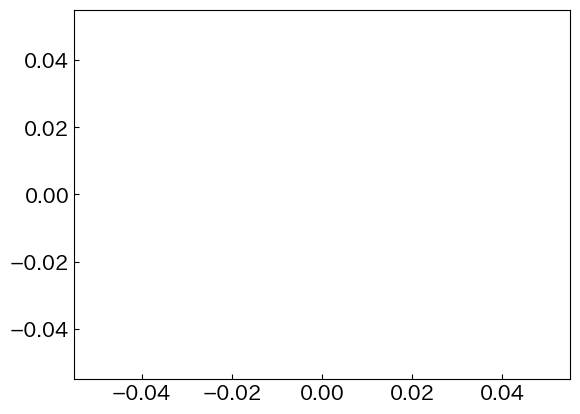

Unnamed: 0      0.000000
dec_min        38.815480
ra_min        308.056761
dec_max        38.854625
ra_max        308.107591
width_pix      59.000000
height_pix     59.000000
ra_center     308.082176
dec_center     38.835053
GLON           78.125051
GLAT           -0.543502
GLON_min       78.097549
GLAT_min       -0.539163
GLON_max       78.152551
GLAT_max       -0.547828
Name: 2, dtype: float64
2
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

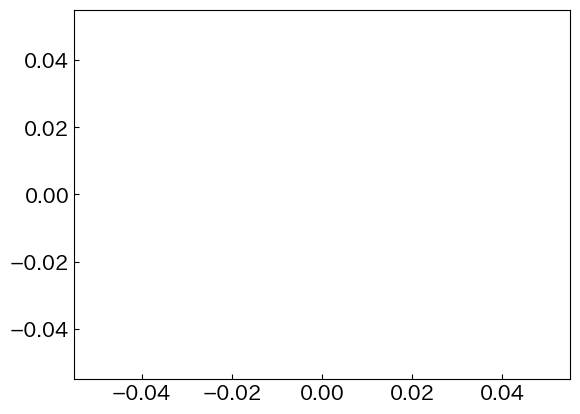

Unnamed: 0      0.000000
dec_min        40.250445
ra_min        308.097562
dec_max        40.298526
ra_max        308.160910
width_pix      73.000000
height_pix     72.000000
ra_center     308.129236
dec_center     40.274486
GLON           79.305317
GLAT            0.281292
GLON_min       79.271624
GLAT_min        0.286483
GLON_max       79.339007
GLAT_max        0.276120
Name: 3, dtype: float64
3
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

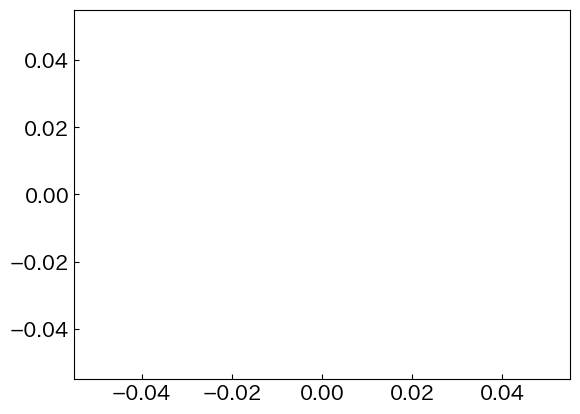

Unnamed: 0      0.000000
dec_min        37.276328
ra_min        306.827304
dec_max        37.312209
ra_max        306.873721
width_pix      55.000000
height_pix     55.000000
ra_center     306.850512
dec_center     37.294268
GLON           76.308460
GLAT           -0.664082
GLON_min       76.283122
GLAT_min       -0.659506
GLON_max       76.333795
GLAT_max       -0.668649
Name: 4, dtype: float64
4
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

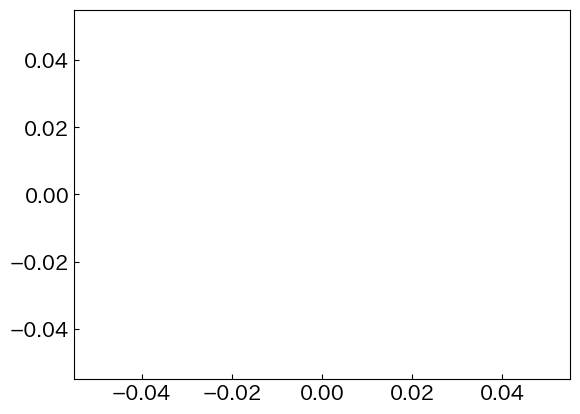

Unnamed: 0      0.000000
dec_min        38.827698
ra_min        308.070601
dec_max        38.896838
ra_max        308.155209
width_pix      99.000000
height_pix    104.000000
ra_center     308.112905
dec_center     38.862268
GLON           78.161159
GLAT           -0.546625
GLON_min       78.113782
GLAT_min       -0.540602
GLON_max       78.208529
GLAT_max       -0.552613
Name: 5, dtype: float64
5
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

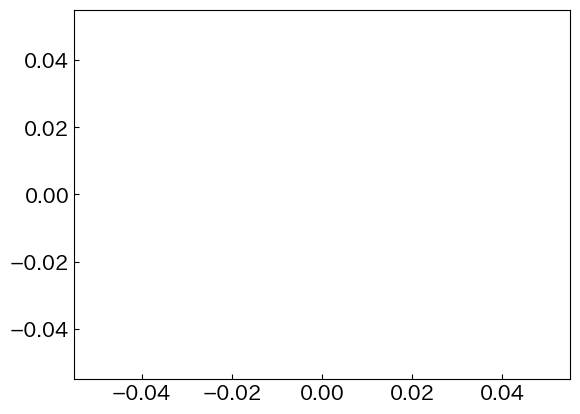

Unnamed: 0      0.000000
dec_min        41.186226
ra_min        305.167194
dec_max        41.226747
ra_max        305.223603
width_pix      62.000000
height_pix     63.000000
ra_center     305.195399
dec_center     41.206486
GLON           78.774787
GLAT            2.632423
GLON_min       78.746039
GLAT_min        2.638440
GLON_max       78.803533
GLAT_max        2.626421
Name: 6, dtype: float64
6
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

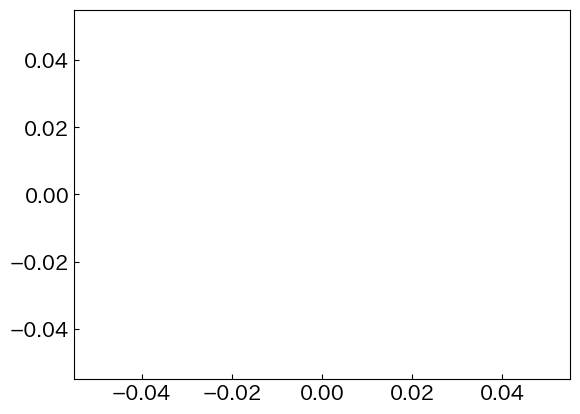

Unnamed: 0      0.000000
dec_min        38.937297
ra_min        307.903431
dec_max        39.005556
ra_max        307.989512
width_pix     100.000000
height_pix    102.000000
ra_center     307.946472
dec_center     38.971426
GLON           78.172351
GLAT           -0.377631
GLON_min       78.125032
GLAT_min       -0.370840
GLON_max       78.219663
GLAT_max       -0.384386
Name: 7, dtype: float64
7
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

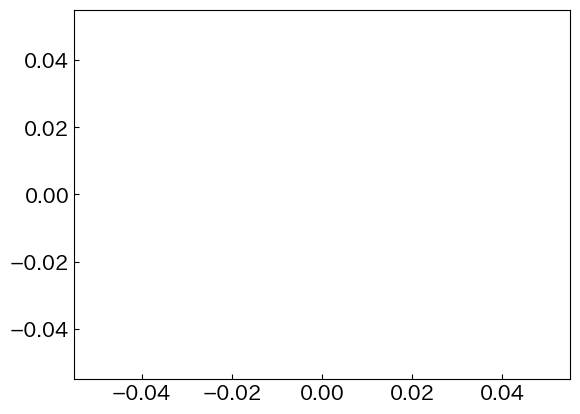

Unnamed: 0      0.000000
dec_min        39.673722
ra_min        310.445574
dec_max        39.722820
ra_max        310.503819
width_pix      69.000000
height_pix     72.000000
ra_center     310.474696
dec_center     39.698271
GLON           79.931768
GLAT           -1.498849
GLON_min       79.898619
GLAT_min       -1.496250
GLON_max       79.964914
GLAT_max       -1.501430
Name: 8, dtype: float64
8
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

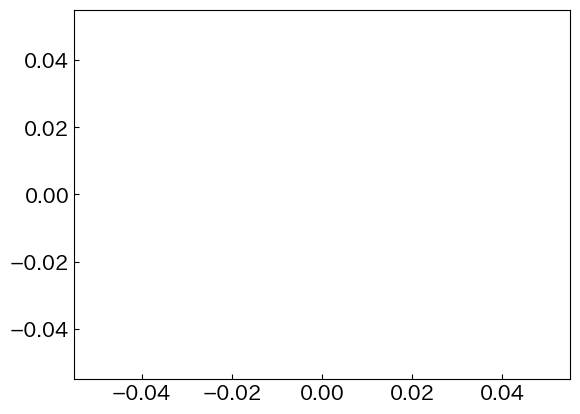

Unnamed: 0      0.000000
dec_min        42.253673
ra_min        309.339162
dec_max        42.280251
ra_max        309.373672
width_pix      38.000000
height_pix     39.000000
ra_center     309.356417
dec_center     42.266962
GLON           81.453285
GLAT            0.736287
GLON_min       81.434977
GLAT_min        0.738427
GLON_max       81.471591
GLAT_max        0.734153
Name: 9, dtype: float64
9
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.875

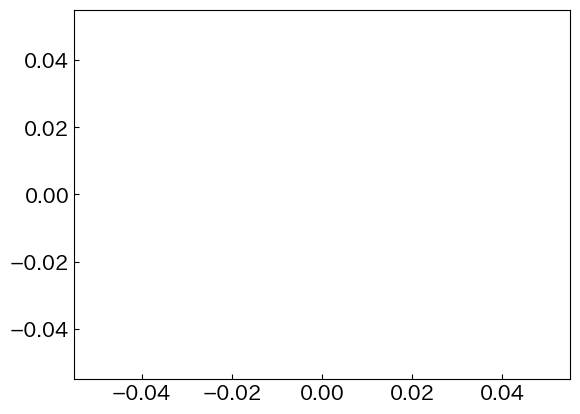

Unnamed: 0      0.000000
dec_min        37.363243
ra_min        306.307751
dec_max        37.405646
ra_max        306.364960
width_pix      67.000000
height_pix     65.000000
ra_center     306.336355
dec_center     37.384444
GLON           76.144903
GLAT           -0.278743
GLON_min       76.114466
GLAT_min       -0.272427
GLON_max       76.175337
GLAT_max       -0.285044
Name: 10, dtype: float64
10
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

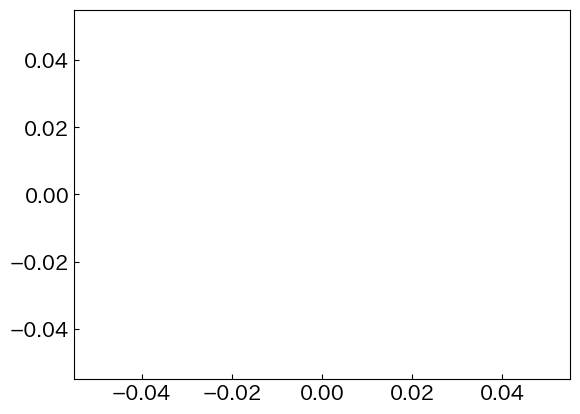

Unnamed: 0      0.000000
dec_min        37.500501
ra_min        305.373834
dec_max        37.544611
ra_max        305.432605
width_pix      68.000000
height_pix     68.000000
ra_center     305.403220
dec_center     37.522556
GLON           75.833177
GLAT            0.407285
GLON_min       75.801773
GLAT_min        0.413891
GLON_max       75.864579
GLAT_max        0.400695
Name: 11, dtype: float64
11
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

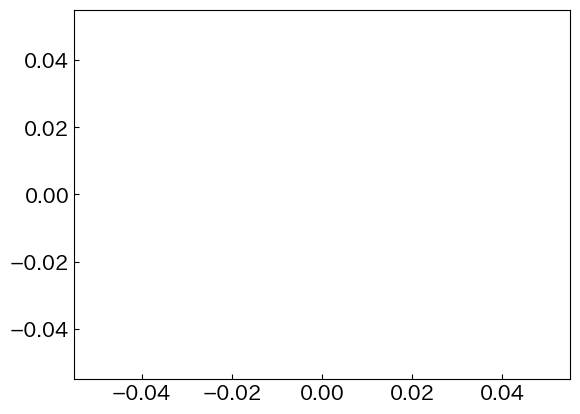

Unnamed: 0      0.000000
dec_min        40.829334
ra_min        307.015700
dec_max        40.900314
ra_max        307.109247
width_pix     105.000000
height_pix    107.000000
ra_center     307.062473
dec_center     40.864824
GLON           79.305563
GLAT            1.283843
GLON_min       79.256083
GLAT_min        1.291868
GLON_max       79.355036
GLAT_max        1.275858
Name: 12, dtype: float64
12
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

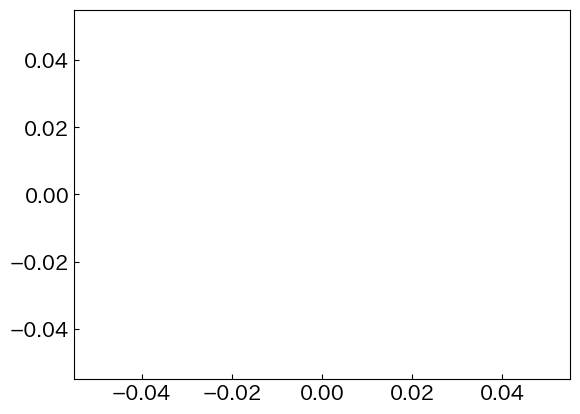

Unnamed: 0      0.000000
dec_min        42.082235
ra_min        309.584376
dec_max        42.127088
ra_max        309.642958
width_pix      66.000000
height_pix     66.000000
ra_center     309.613667
dec_center     42.104662
GLON           81.439614
GLAT            0.486310
GLON_min       81.408598
GLAT_min        0.489978
GLON_max       81.470627
GLAT_max        0.482659
Name: 13, dtype: float64
13
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

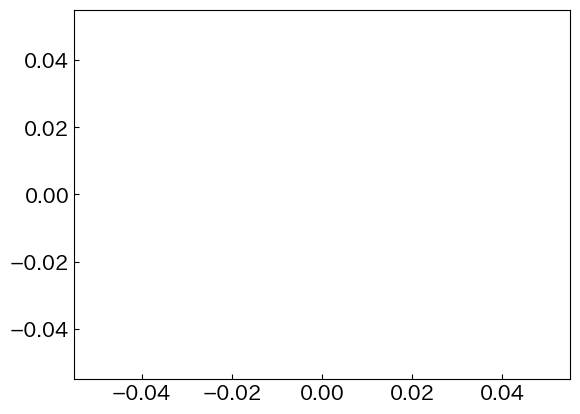

Unnamed: 0      0.000000
dec_min        41.147462
ra_min        309.720331
dec_max        41.414356
ra_max        310.052380
width_pix     383.000000
height_pix    392.000000
ra_center     309.886356
dec_center     41.280909
GLON           80.909593
GLAT           -0.176345
GLON_min       80.727693
GLAT_min       -0.158489
GLON_max       81.091372
GLAT_max       -0.193649
Name: 14, dtype: float64
14
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

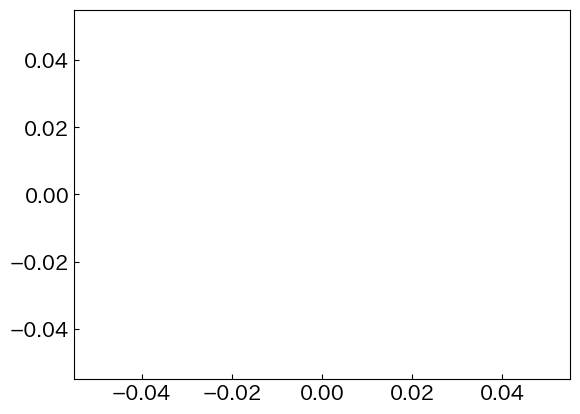

Unnamed: 0      0.000000
dec_min        39.418817
ra_min        306.732905
dec_max        39.483551
ra_max        306.815468
width_pix      95.000000
height_pix     98.000000
ra_center     306.774186
dec_center     39.451184
GLON           78.028035
GLAT            0.639395
GLON_min       77.983163
GLAT_min        0.646529
GLON_max       78.072902
GLAT_max        0.632293
Name: 15, dtype: float64
15
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

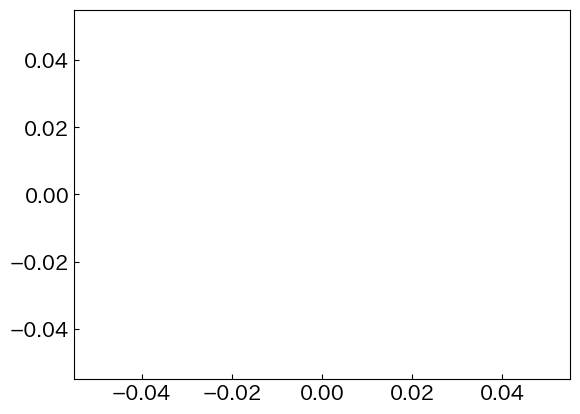

Unnamed: 0      0.000000
dec_min        39.373707
ra_min        306.725569
dec_max        39.495711
ra_max        306.890878
width_pix     189.000000
height_pix    185.000000
ra_center     306.808223
dec_center     39.434709
GLON           78.029918
GLAT            0.608431
GLON_min       77.943150
GLAT_min        0.624935
GLON_max       78.116667
GLAT_max        0.592050
Name: 16, dtype: float64
16
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

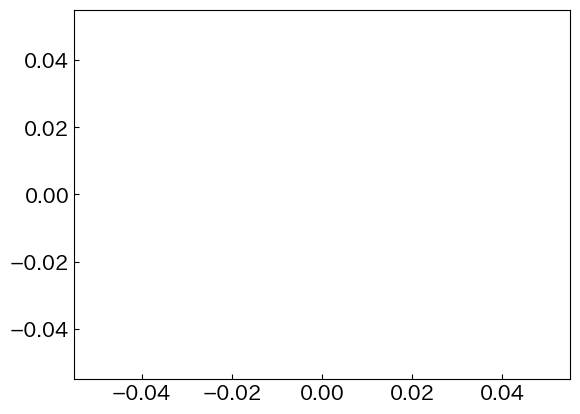

Unnamed: 0      0.000000
dec_min        39.863763
ra_min        308.728812
dec_max        40.000478
ra_max        308.903299
width_pix     203.000000
height_pix    204.000000
ra_center     308.816056
dec_center     39.932121
GLON           79.343979
GLAT           -0.344563
GLON_min       79.249144
GLAT_min       -0.331949
GLON_max       79.438788
GLAT_max       -0.357030
Name: 17, dtype: float64
17
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

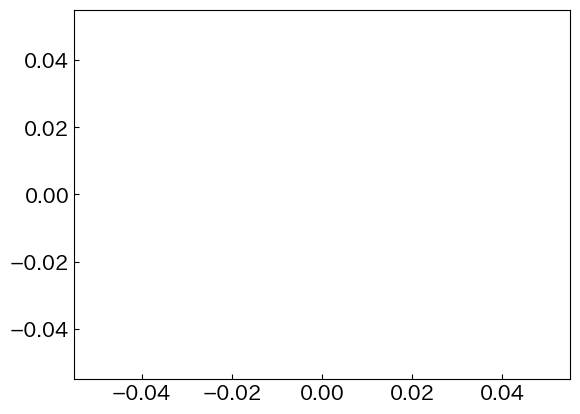

Unnamed: 0      0.000000
dec_min        41.244437
ra_min        307.577544
dec_max        41.289064
ra_max        307.637883
width_pix      68.000000
height_pix     67.000000
ra_center     307.607713
dec_center     41.266750
GLON           79.872294
GLAT            1.186373
GLON_min       79.840899
GLAT_min        1.191579
GLON_max       79.903686
GLAT_max        1.181183
Name: 18, dtype: float64
18
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

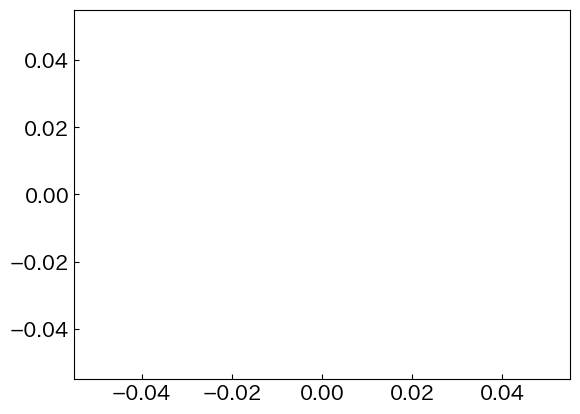

Unnamed: 0      0.000000
dec_min        37.659868
ra_min        305.433970
dec_max        37.699818
ra_max        305.487042
width_pix      61.000000
height_pix     62.000000
ra_center     305.460506
dec_center     37.679843
GLON           75.988303
GLAT            0.459595
GLON_min       75.959919
GLAT_min        0.465473
GLON_max       76.016686
GLAT_max        0.453730
Name: 19, dtype: float64
19
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

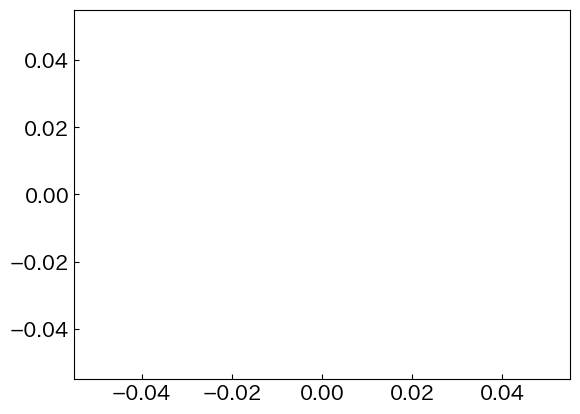

Unnamed: 0      0.000000
dec_min        41.618197
ra_min        308.770113
dec_max        41.655976
ra_max        308.819918
width_pix      56.000000
height_pix     57.000000
ra_center     308.795015
dec_center     41.637087
GLON           80.698932
GLAT            0.690490
GLON_min       80.672653
GLAT_min        0.694069
GLON_max       80.725209
GLAT_max        0.686922
Name: 20, dtype: float64
20
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

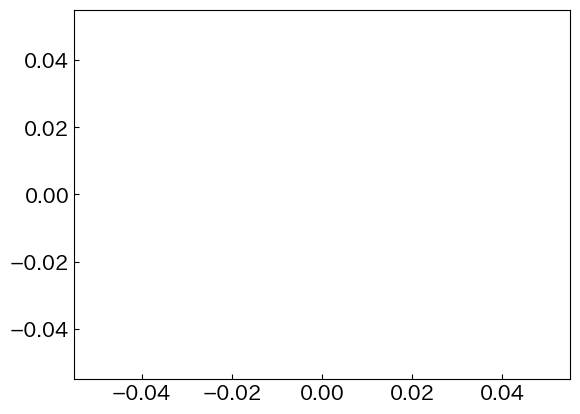

Unnamed: 0      0.000000
dec_min        42.197334
ra_min        310.359551
dec_max        42.242291
ra_max        310.416584
width_pix      66.000000
height_pix     66.000000
ra_center     310.388068
dec_center     42.219812
GLON           81.881274
GLAT            0.101991
GLON_min       81.850563
GLAT_min        0.104863
GLON_max       81.911982
GLAT_max        0.099136
Name: 21, dtype: float64
21
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

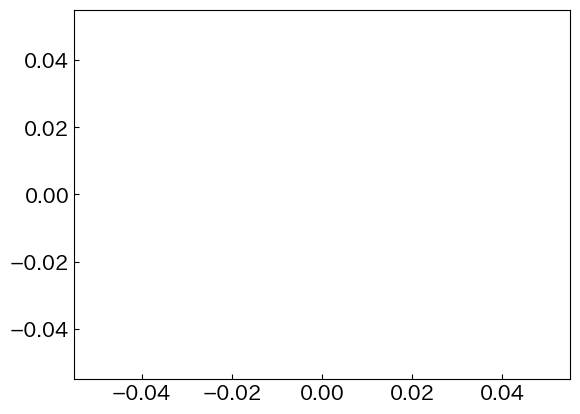

Unnamed: 0      0.000000
dec_min        37.631898
ra_min        305.953072
dec_max        37.668758
ra_max        306.000379
width_pix      55.000000
height_pix     57.000000
ra_center     305.976726
dec_center     37.650328
GLON           76.197931
GLAT            0.107583
GLON_min       76.172087
GLAT_min        0.112330
GLON_max       76.223775
GLAT_max        0.102846
Name: 22, dtype: float64
22
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

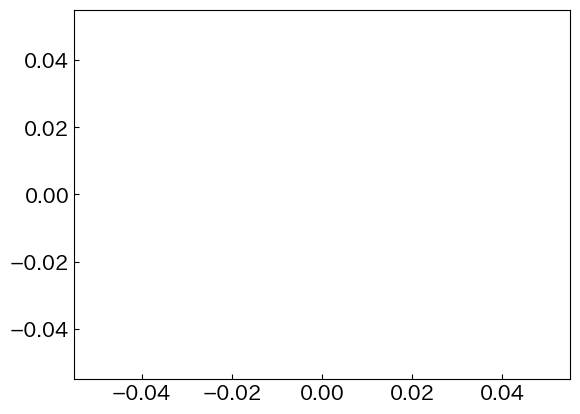

Unnamed: 0      0.000000
dec_min        40.131729
ra_min        308.438273
dec_max        40.164999
ra_max        308.478856
width_pix      47.000000
height_pix     49.000000
ra_center     308.458565
dec_center     40.148364
GLON           79.353589
GLAT            0.004115
GLON_min       79.330985
GLAT_min        0.006645
GLON_max       79.376191
GLAT_max        0.001593
Name: 23, dtype: float64
23
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

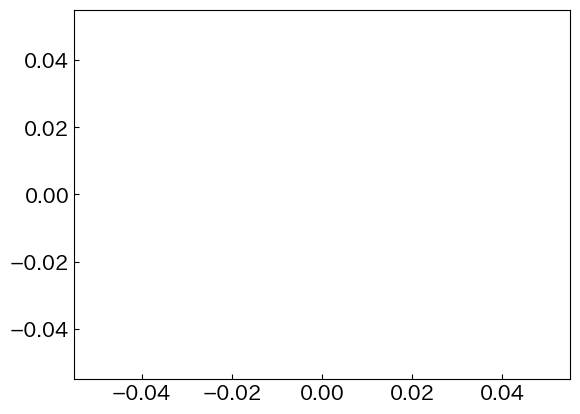

Unnamed: 0      0.000000
dec_min        39.010612
ra_min        307.386915
dec_max        39.051345
ra_max        307.440244
width_pix      62.000000
height_pix     61.000000
ra_center     307.413579
dec_center     39.030979
GLON           77.976333
GLAT           -0.008001
GLON_min       77.947684
GLAT_min       -0.003185
GLON_max       78.004980
GLAT_max       -0.012804
Name: 24, dtype: float64
24
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

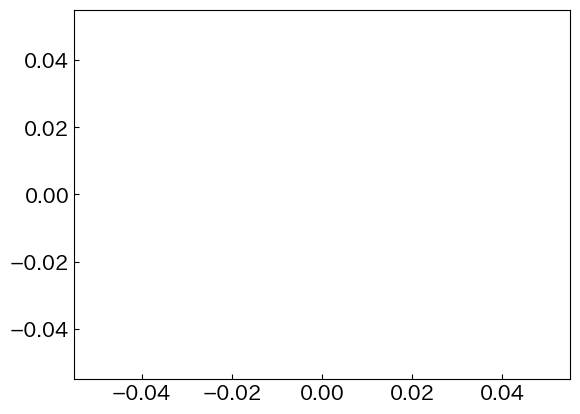

Unnamed: 0      0.000000
dec_min        40.271693
ra_min        307.741944
dec_max        40.308595
ra_max        307.788740
width_pix      54.000000
height_pix     56.000000
ra_center     307.765342
dec_center     40.290144
GLON           79.153634
GLAT            0.514320
GLON_min       79.128204
GLAT_min        0.517843
GLON_max       79.179063
GLAT_max        0.510808
Name: 25, dtype: float64
25
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

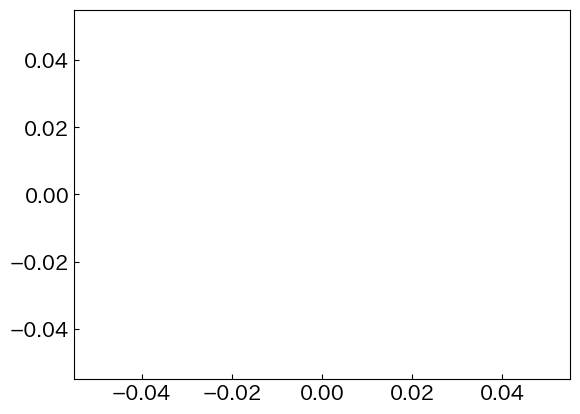

Unnamed: 0      0.000000
dec_min        39.729659
ra_min        304.998041
dec_max        39.793908
ra_max        305.087138
width_pix     100.000000
height_pix     99.000000
ra_center     305.042590
dec_center     39.761783
GLON           77.517102
GLAT            1.910338
GLON_min       77.471211
GLAT_min        1.920419
GLON_max       77.562988
GLAT_max        1.900293
Name: 26, dtype: float64
26
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

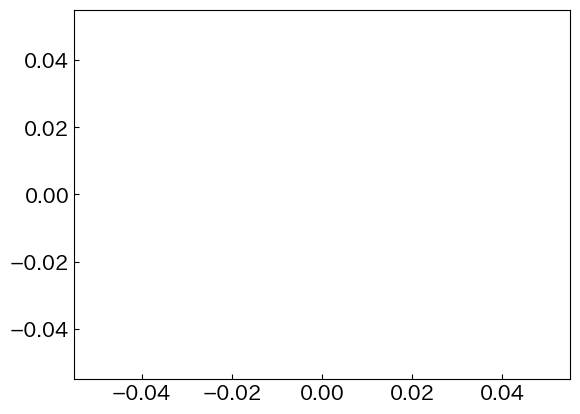

Unnamed: 0      0.000000
dec_min        37.635489
ra_min        305.984909
dec_max        37.671078
ra_max        306.033157
width_pix      56.000000
height_pix     54.000000
ra_center     306.009033
dec_center     37.653284
GLON           76.215048
GLAT            0.088347
GLON_min       76.189508
GLAT_min        0.093754
GLON_max       76.240587
GLAT_max        0.082950
Name: 27, dtype: float64
27
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

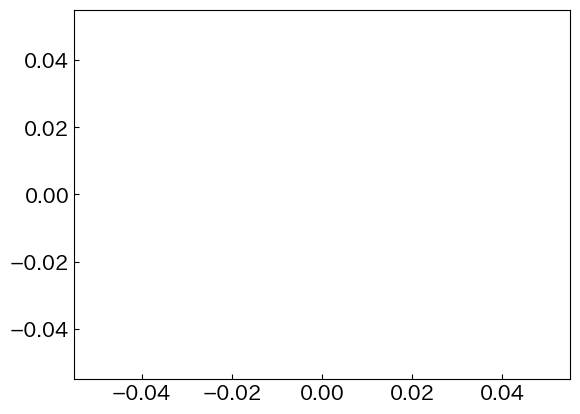

Unnamed: 0      0.000000
dec_min        38.906021
ra_min        307.737067
dec_max        39.146179
ra_max        308.055607
width_pix     370.000000
height_pix    361.000000
ra_center     307.896337
dec_center     39.026100
GLON           78.193377
GLAT           -0.313872
GLON_min       78.023335
GLAT_min       -0.284880
GLON_max       78.363347
GLAT_max       -0.342395
Name: 28, dtype: float64
28
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

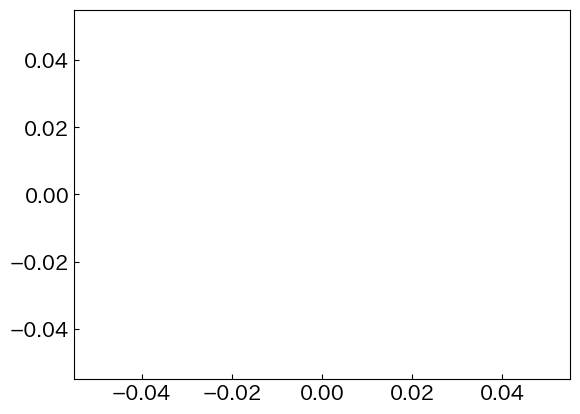

Unnamed: 0      0.000000
dec_min        39.808827
ra_min        307.559152
dec_max        39.843506
ra_max        307.606253
width_pix      54.000000
height_pix     52.000000
ra_center     307.582702
dec_center     39.826166
GLON           78.696409
GLAT            0.353779
GLON_min       78.671744
GLAT_min        0.358200
GLON_max       78.721072
GLAT_max        0.349368
Name: 29, dtype: float64
29
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

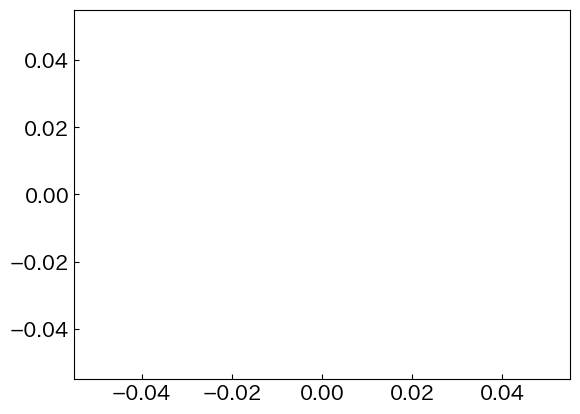

Unnamed: 0      0.000000
dec_min        39.387028
ra_min        306.776880
dec_max        39.453698
ra_max        306.863243
width_pix      98.000000
height_pix    101.000000
ra_center     306.820061
dec_center     39.420363
GLON           78.023568
GLAT            0.592648
GLON_min       77.977043
GLAT_min        0.600402
GLON_max       78.070088
GLAT_max        0.584928
Name: 30, dtype: float64
30
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

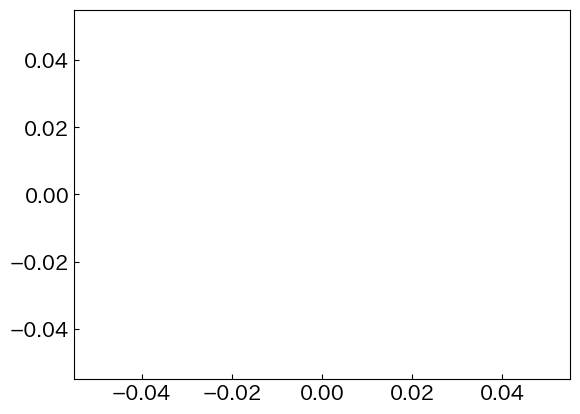

Unnamed: 0      0.000000
dec_min        42.828093
ra_min        310.494442
dec_max        43.037899
ra_max        310.774489
width_pix     317.000000
height_pix    306.000000
ra_center     310.634465
dec_center     42.932996
GLON           82.555143
GLAT            0.397727
GLON_min       82.409304
GLAT_min        0.413988
GLON_max       82.700902
GLAT_max        0.381844
Name: 31, dtype: float64
31
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

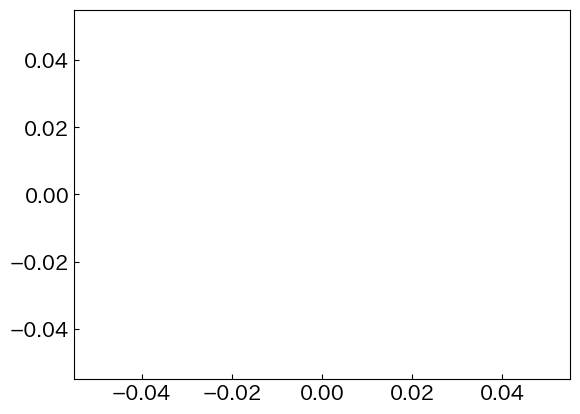

Unnamed: 0      0.000000
dec_min        39.887110
ra_min        308.792533
dec_max        39.946620
ra_max        308.868807
width_pix      89.000000
height_pix     88.000000
ra_center     308.830670
dec_center     39.916865
GLON           79.338494
GLAT           -0.362681
GLON_min       79.297138
GLAT_min       -0.357111
GLON_max       79.379845
GLAT_max       -0.368223
Name: 32, dtype: float64
32
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

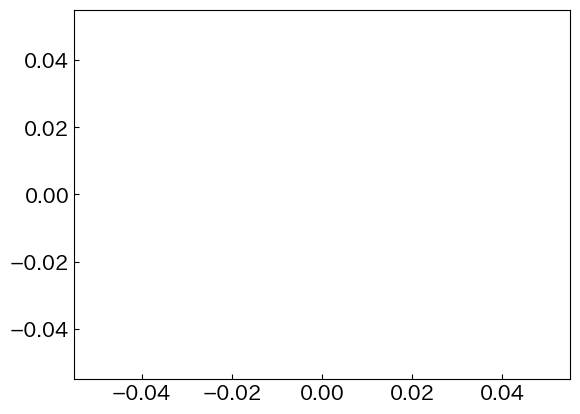

Unnamed: 0      0.000000
dec_min        43.008070
ra_min        307.568359
dec_max        43.032580
ra_max        307.602322
width_pix      37.000000
height_pix     37.000000
ra_center     307.585340
dec_center     43.020325
GLON           81.281284
GLAT            2.231298
GLON_min       81.264058
GLAT_min        2.234141
GLON_max       81.298509
GLAT_max        2.228460
Name: 33, dtype: float64
33
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

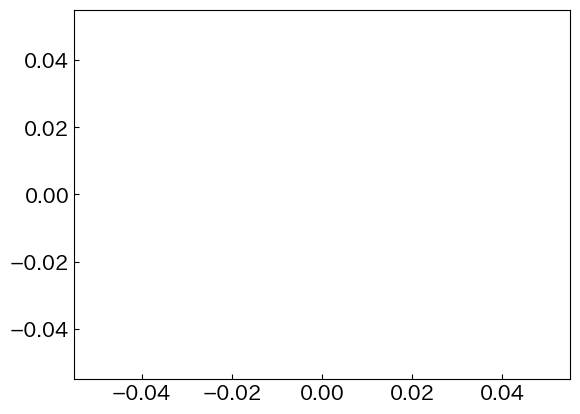

Unnamed: 0      0.000000
dec_min        41.885857
ra_min        304.483845
dec_max        41.916588
ra_max        304.529989
width_pix      50.000000
height_pix     48.000000
ra_center     304.506917
dec_center     41.901222
GLON           79.059210
GLAT            3.449383
GLON_min       79.036825
GLAT_min        3.455019
GLON_max       79.081594
GLAT_max        3.443756
Name: 34, dtype: float64
34
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

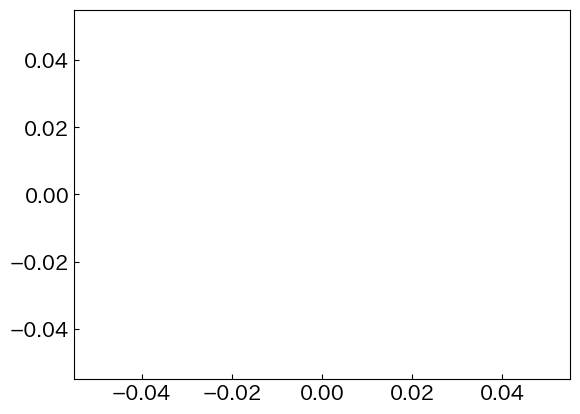

Unnamed: 0      0.000000
dec_min        38.984306
ra_min        307.276472
dec_max        39.126545
ra_max        307.460980
width_pix     214.000000
height_pix    215.000000
ra_center     307.368726
dec_center     39.055426
GLON           77.975681
GLAT            0.034552
GLON_min       77.876044
GLAT_min        0.050918
GLON_max       78.075291
GLAT_max        0.018346
Name: 35, dtype: float64
35
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

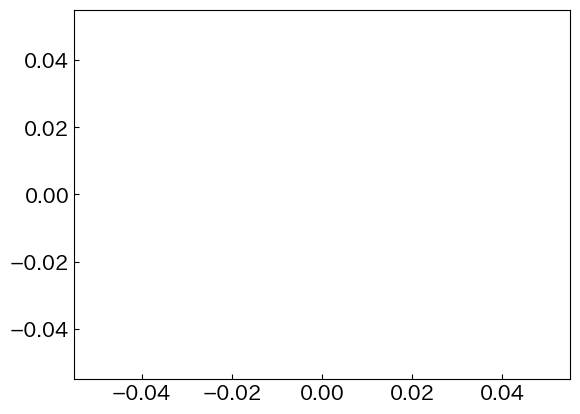

Unnamed: 0      0.000000
dec_min        39.249011
ra_min        305.157646
dec_max        39.277841
ra_max        305.196803
width_pix      45.000000
height_pix     45.000000
ra_center     305.177225
dec_center     39.263426
GLON           77.165086
GLAT            1.542444
GLON_min       77.144608
GLAT_min        1.546757
GLON_max       77.185562
GLAT_max        1.538138
Name: 36, dtype: float64
36
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

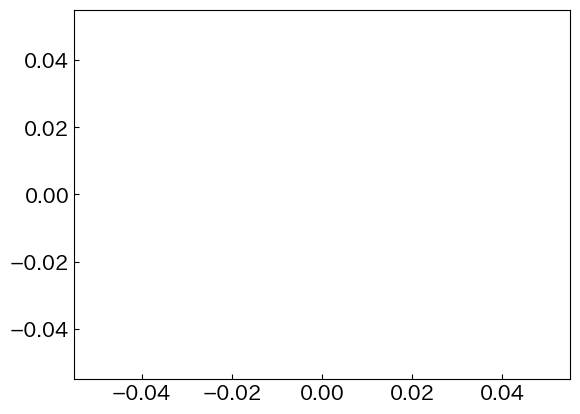

Unnamed: 0      0.000000
dec_min        39.339864
ra_min        304.379480
dec_max        39.383803
ra_max        304.436849
width_pix      64.000000
height_pix     68.000000
ra_center     304.408164
dec_center     39.361834
GLON           76.910831
GLAT            2.089393
GLON_min       76.880187
GLAT_min        2.095463
GLON_max       76.941473
GLAT_max        2.083339
Name: 37, dtype: float64
37
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

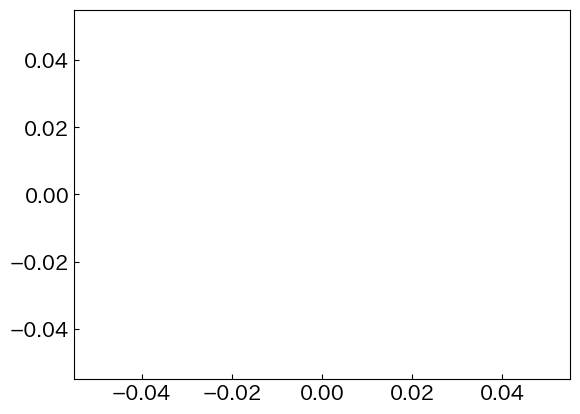

Unnamed: 0      0.000000
dec_min        39.513368
ra_min        305.147019
dec_max        39.622794
ra_max        305.291559
width_pix     162.000000
height_pix    169.000000
ra_center     305.219289
dec_center     39.568081
GLON           77.434519
GLAT            1.688507
GLON_min       77.357815
GLAT_min        1.703383
GLON_max       77.511209
GLAT_max        1.673726
Name: 38, dtype: float64
38
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

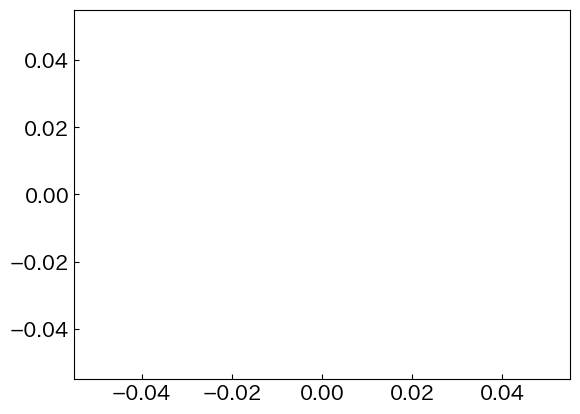

Unnamed: 0      0.000000
dec_min        39.276776
ra_min        304.343369
dec_max        39.411265
ra_max        304.530872
width_pix     210.000000
height_pix    210.000000
ra_center     304.437120
dec_center     39.344020
GLON           76.908623
GLAT            2.060867
GLON_min       76.812224
GLAT_min        2.083295
GLON_max       77.005003
GLAT_max        2.038590
Name: 39, dtype: float64
39
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

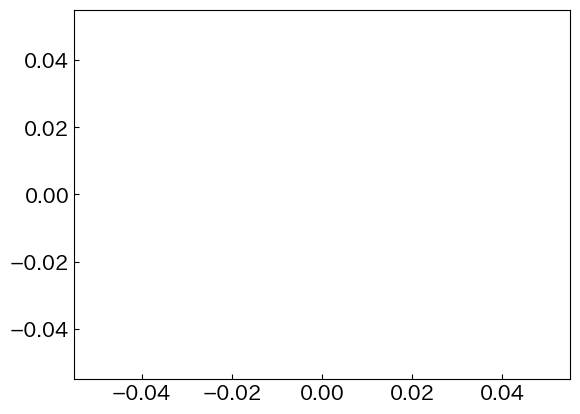

Unnamed: 0      0.000000
dec_min        41.560171
ra_min        309.036912
dec_max        41.590686
ra_max        309.076194
width_pix      45.000000
height_pix     46.000000
ra_center     309.056553
dec_center     41.575428
GLON           80.767103
GLAT            0.497104
GLON_min       80.746073
GLAT_min        0.499658
GLON_max       80.788131
GLAT_max        0.494557
Name: 40, dtype: float64
40
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

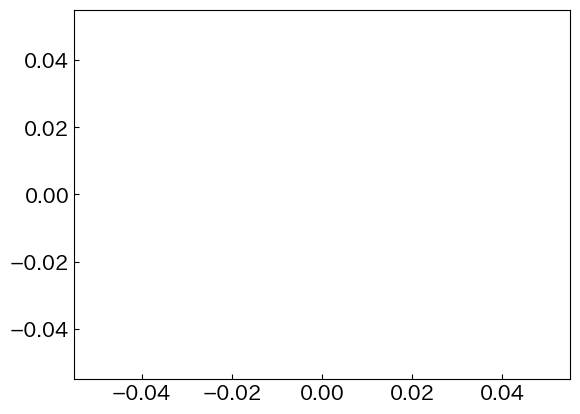

Unnamed: 0      0.000000
dec_min        40.701894
ra_min        307.508423
dec_max        40.725882
ra_max        307.539819
width_pix      35.000000
height_pix     36.000000
ra_center     307.524121
dec_center     40.713888
GLON           79.388018
GLAT            0.912157
GLON_min       79.371318
GLAT_min        0.914733
GLON_max       79.404718
GLAT_max        0.909587
Name: 41, dtype: float64
41
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

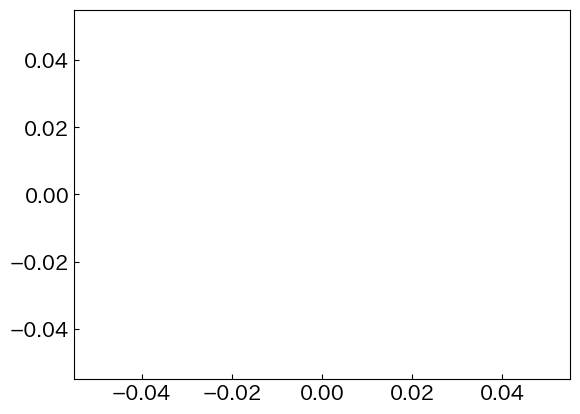

Unnamed: 0      0.000000
dec_min        39.045948
ra_min        304.377717
dec_max        39.075806
ra_max        304.419459
width_pix      47.000000
height_pix     47.000000
ra_center     304.398588
dec_center     39.060877
GLON           76.657230
GLAT            1.926926
GLON_min       76.635772
GLAT_min        1.931990
GLON_max       76.678687
GLAT_max        1.921871
Name: 42, dtype: float64
42
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

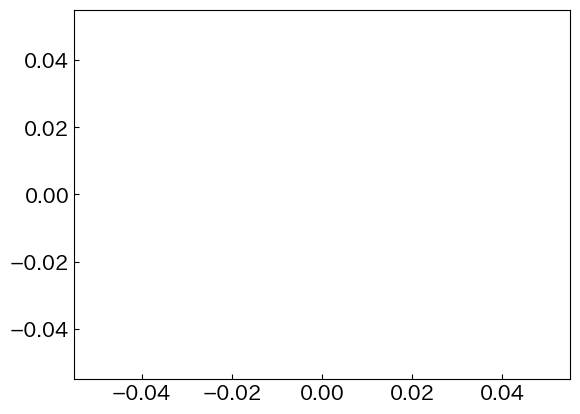

Unnamed: 0      0.000000
dec_min        41.361699
ra_min        309.965766
dec_max        41.453258
ra_max        310.076298
width_pix     128.000000
height_pix    135.000000
ra_center     310.021032
dec_center     41.407479
GLON           81.071565
GLAT           -0.179236
GLON_min       81.009992
GLAT_min       -0.174340
GLON_max       81.133123
GLAT_max       -0.184069
Name: 43, dtype: float64
43
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

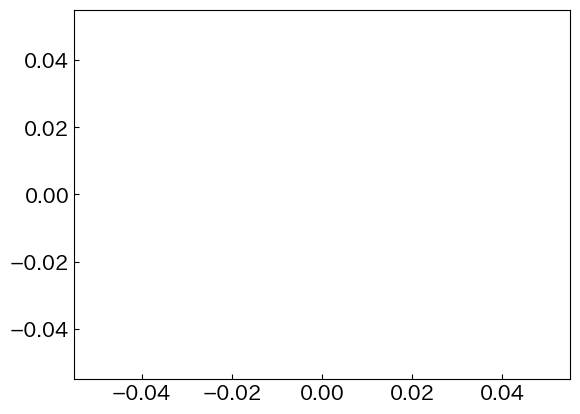

Unnamed: 0      0.000000
dec_min        39.978118
ra_min        306.492145
dec_max        40.104223
ra_max        306.665302
width_pix     196.000000
height_pix    192.000000
ra_center     306.578723
dec_center     40.041171
GLON           78.421268
GLAT            1.104233
GLON_min       78.331445
GLAT_min        1.121779
GLON_max       78.511073
GLAT_max        1.086823
Name: 44, dtype: float64
44
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

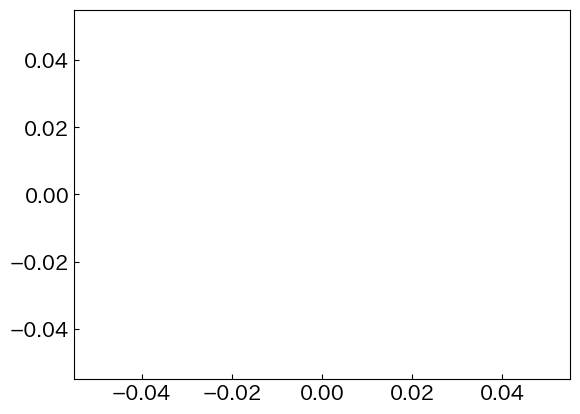

Unnamed: 0      0.000000
dec_min        41.265024
ra_min        305.897285
dec_max        41.298949
ra_max        305.945127
width_pix      53.000000
height_pix     52.000000
ra_center     305.921206
dec_center     41.281987
GLON           79.148123
GLAT            2.226959
GLON_min       79.123901
GLAT_min        2.231973
GLON_max       79.172343
GLAT_max        2.221955
Name: 45, dtype: float64
45
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

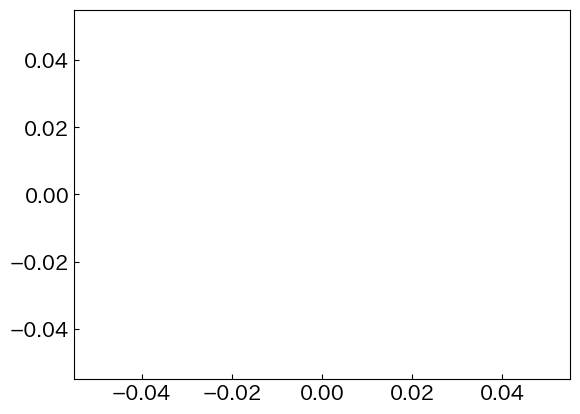

Unnamed: 0      0.000000
dec_min        40.663906
ra_min        306.203994
dec_max        40.689324
ra_max        306.238675
width_pix      39.000000
height_pix     39.000000
ra_center     306.221334
dec_center     40.676615
GLON           78.782649
GLAT            1.693669
GLON_min       78.764676
GLAT_min        1.697100
GLON_max       78.800620
GLAT_max        1.690244
Name: 46, dtype: float64
46
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

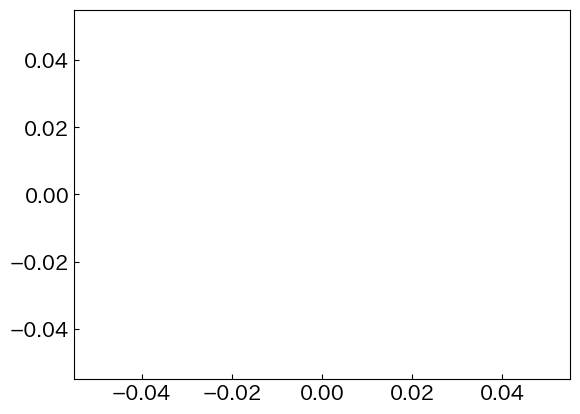

Unnamed: 0      0.000000
dec_min        41.459814
ra_min        309.976616
dec_max        41.493058
ra_max        310.020050
width_pix      50.000000
height_pix     49.000000
ra_center     309.998333
dec_center     41.476436
GLON           81.115784
GLAT           -0.123654
GLON_min       81.092685
GLAT_min       -0.120911
GLON_max       81.138882
GLAT_max       -0.126388
Name: 47, dtype: float64
47
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

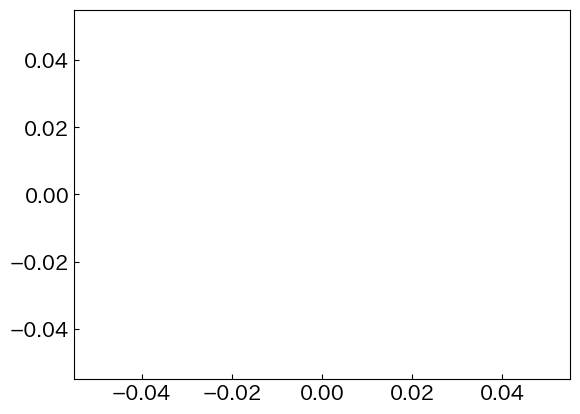

Unnamed: 0      0.000000
dec_min        41.399361
ra_min        308.420262
dec_max        41.422753
ra_max        308.449449
width_pix      33.000000
height_pix     35.000000
ra_center     308.434856
dec_center     41.411057
GLON           80.356515
GLAT            0.771523
GLON_min       80.340598
GLAT_min        0.773340
GLON_max       80.372432
GLAT_max        0.769711
Name: 48, dtype: float64
48
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

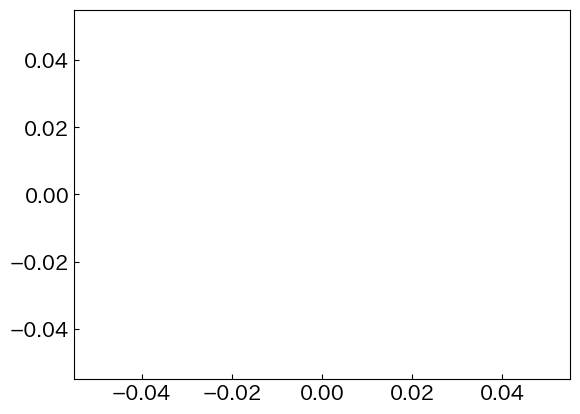

Unnamed: 0      0.000000
dec_min        41.117161
ra_min        308.061058
dec_max        41.153691
ra_max        308.110432
width_pix      56.000000
height_pix     55.000000
ra_center     308.085745
dec_center     41.135426
GLON           79.978855
GLAT            0.818598
GLON_min       79.953119
GLAT_min        0.822744
GLON_max       80.004589
GLAT_max        0.814464
Name: 49, dtype: float64
49
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

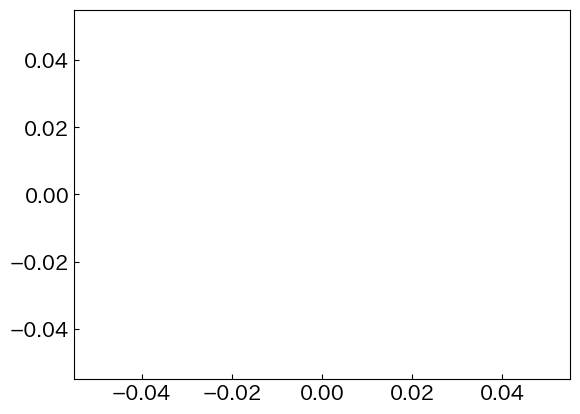

Unnamed: 0      0.000000
dec_min        40.182676
ra_min        305.515269
dec_max        40.305515
ra_max        305.682448
width_pix     186.000000
height_pix    190.000000
ra_center     305.598858
dec_center     40.244096
GLON           78.156443
GLAT            1.833727
GLON_min       78.069543
GLAT_min        1.851142
GLON_max       78.243324
GLAT_max        1.816438
Name: 50, dtype: float64
50
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

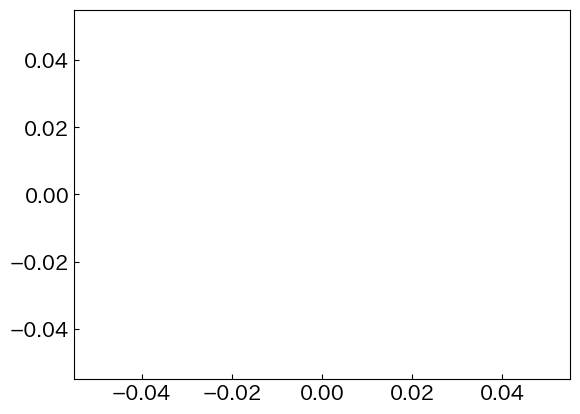

Unnamed: 0      0.000000
dec_min        39.382020
ra_min        305.315810
dec_max        39.416703
ra_max        305.363784
width_pix      54.000000
height_pix     54.000000
ra_center     305.339797
dec_center     39.399361
GLON           77.348450
GLAT            1.516127
GLON_min       77.323636
GLAT_min        1.521521
GLON_max       77.373263
GLAT_max        1.510743
Name: 51, dtype: float64
51
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

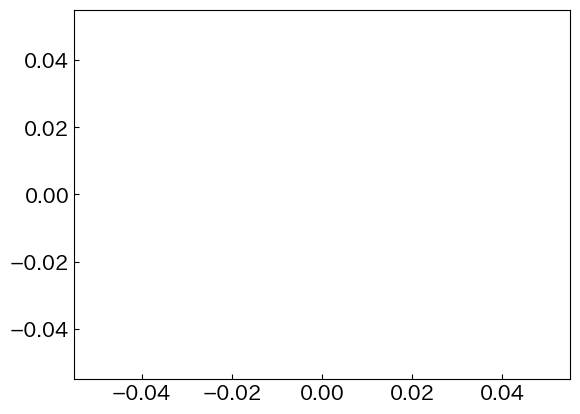

Unnamed: 0      0.000000
dec_min        42.070001
ra_min        309.318073
dec_max        42.332882
ra_max        309.650368
width_pix     376.000000
height_pix    388.000000
ra_center     309.484220
dec_center     42.201441
GLON           81.458385
GLAT            0.621304
GLON_min       81.279178
GLAT_min        0.639888
GLON_max       81.637472
GLAT_max        0.603267
Name: 52, dtype: float64
52
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

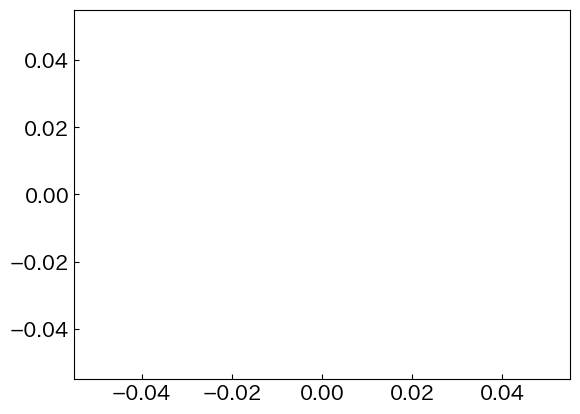

Unnamed: 0      0.000000
dec_min        40.025900
ra_min        304.762955
dec_max        40.091374
ra_max        304.853630
width_pix     101.000000
height_pix    102.000000
ra_center     304.808292
dec_center     40.058637
GLON           77.660724
GLAT            2.226281
GLON_min       77.614088
GLAT_min        2.236518
GLON_max       77.707355
GLAT_max        2.216081
Name: 53, dtype: float64
53
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

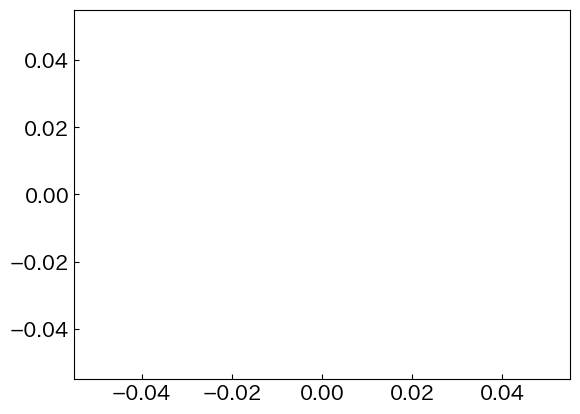

Unnamed: 0      0.000000
dec_min        39.946584
ra_min        306.623857
dec_max        39.968869
ra_max        306.652713
width_pix      33.000000
height_pix     34.000000
ra_center     306.638285
dec_center     39.957726
GLON           78.379729
GLAT            1.018677
GLON_min       78.364235
GLAT_min        1.021224
GLON_max       78.395222
GLAT_max        1.016134
Name: 54, dtype: float64
54
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

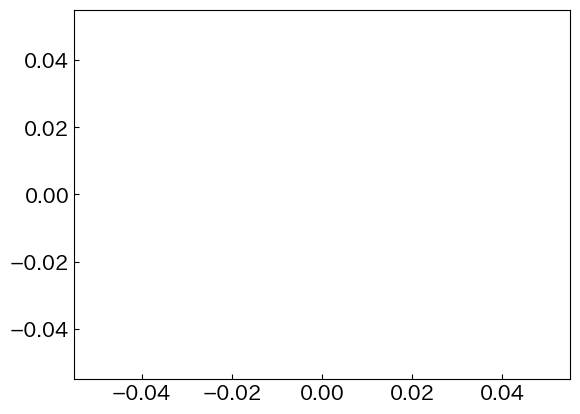

Unnamed: 0      0.000000
dec_min        37.328035
ra_min        306.295489
dec_max        37.413629
ra_max        306.405326
width_pix     128.000000
height_pix    131.000000
ra_center     306.350408
dec_center     37.370832
GLON           76.140241
GLAT           -0.295721
GLON_min       76.080090
GLAT_min       -0.284793
GLON_max       76.200385
GLAT_max       -0.306594
Name: 55, dtype: float64
55
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

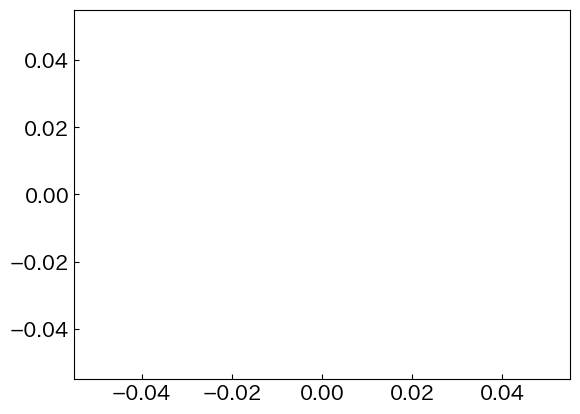

Unnamed: 0      0.000000
dec_min        41.570895
ra_min        308.737805
dec_max        41.595468
ra_max        308.769760
width_pix      36.000000
height_pix     36.000000
ra_center     308.753782
dec_center     41.583181
GLON           80.637299
GLAT            0.682866
GLON_min       80.620300
GLAT_min        0.685077
GLON_max       80.654297
GLAT_max        0.680660
Name: 56, dtype: float64
56
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

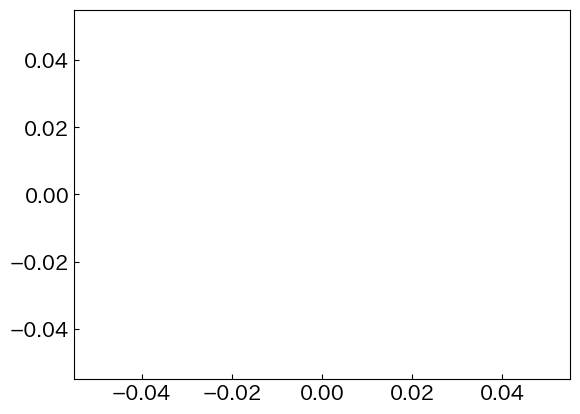

Unnamed: 0      0.000000
dec_min        40.916066
ra_min        304.894592
dec_max        40.959012
ra_max        304.952911
width_pix      64.000000
height_pix     67.000000
ra_center     304.923751
dec_center     40.937539
GLON           78.436810
GLAT            2.649318
GLON_min       78.406620
GLAT_min        2.655400
GLON_max       78.466997
GLAT_max        2.643251
Name: 57, dtype: float64
57
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

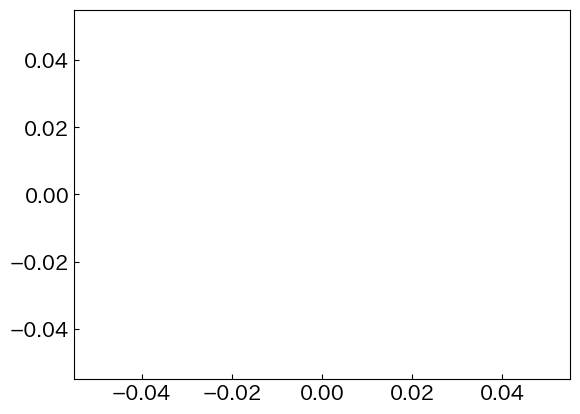

Unnamed: 0      0.000000
dec_min        40.220255
ra_min        308.083321
dec_max        40.309686
ra_max        308.199555
width_pix     133.000000
height_pix    134.000000
ra_center     308.141438
dec_center     40.264970
GLON           79.303186
GLAT            0.268152
GLON_min       79.240870
GLAT_min        0.277329
GLON_max       79.365490
GLAT_max        0.259039
Name: 58, dtype: float64
58
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

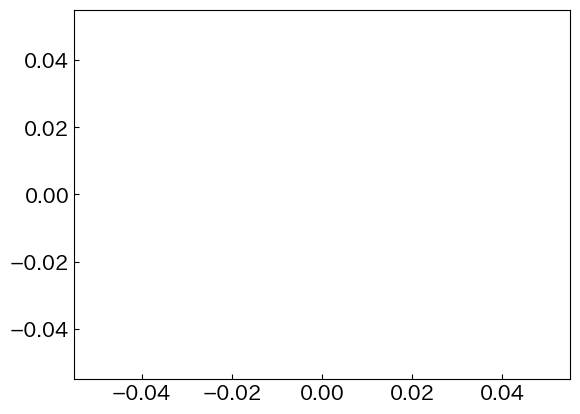

Unnamed: 0      0.000000
dec_min        39.288532
ra_min        305.629291
dec_max        39.322261
ra_max        305.676587
width_pix      54.000000
height_pix     52.000000
ra_center     305.652939
dec_center     39.305396
GLON           77.409272
GLAT            1.263611
GLON_min       77.384970
GLAT_min        1.268997
GLON_max       77.433573
GLAT_max        1.258235
Name: 59, dtype: float64
59
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

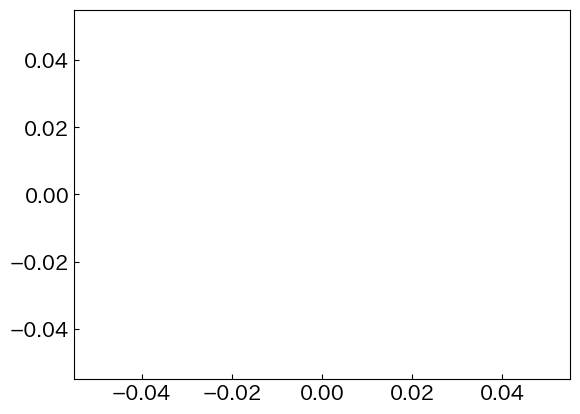

Unnamed: 0      0.000000
dec_min        37.388218
ra_min        306.817847
dec_max        37.443918
ra_max        306.889966
width_pix      85.000000
height_pix     85.000000
ra_center     306.853906
dec_center     37.416068
GLON           76.409076
GLAT           -0.595380
GLON_min       76.369756
GLAT_min       -0.588291
GLON_max       76.448393
GLAT_max       -0.602445
Name: 60, dtype: float64
60
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

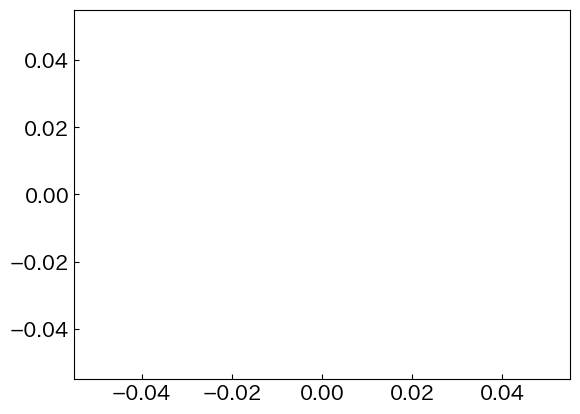

Unnamed: 0      0.000000
dec_min        39.040904
ra_min        306.518150
dec_max        39.076168
ra_max        306.566341
width_pix      56.000000
height_pix     53.000000
ra_center     306.542245
dec_center     39.058536
GLON           77.604023
GLAT            0.557774
GLON_min       77.578810
GLAT_min        0.562814
GLON_max       77.629235
GLAT_max        0.552744
Name: 61, dtype: float64
61
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

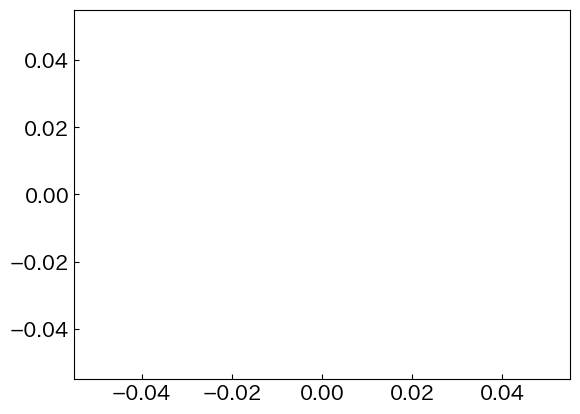

Unnamed: 0      0.000000
dec_min        42.427736
ra_min        310.643302
dec_max        42.445023
ra_max        310.665367
width_pix      25.000000
height_pix     25.000000
ra_center     310.654335
dec_center     42.436379
GLON           82.173116
GLAT            0.080081
GLON_min       82.161290
GLAT_min        0.081163
GLON_max       82.184941
GLAT_max        0.079001
Name: 62, dtype: float64
62
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

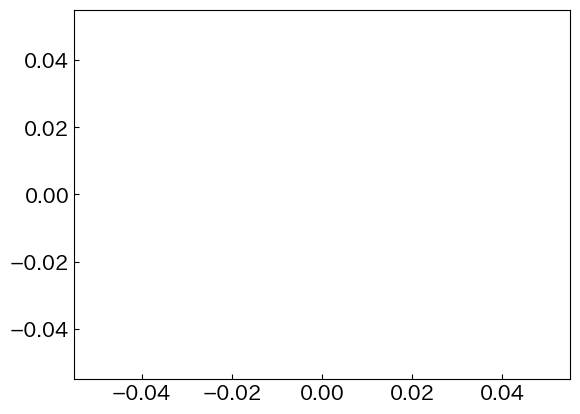

Unnamed: 0      0.000000
dec_min        37.353969
ra_min        306.824420
dec_max        37.396556
ra_max        306.877697
width_pix      63.000000
height_pix     65.000000
ra_center     306.851059
dec_center     37.375263
GLON           76.374577
GLAT           -0.617292
GLON_min       76.344938
GLAT_min       -0.612466
GLON_max       76.404214
GLAT_max       -0.622105
Name: 63, dtype: float64
63
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

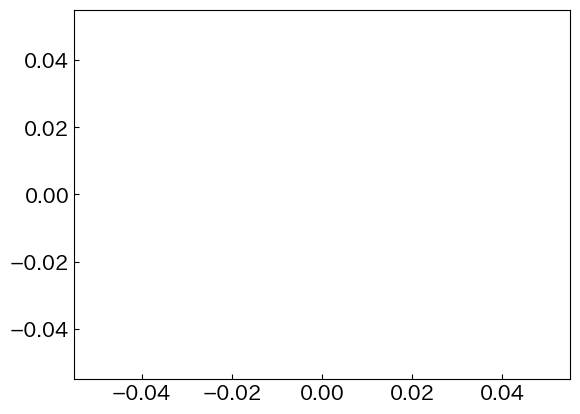

Unnamed: 0      0.000000
dec_min        41.068803
ra_min        304.614582
dec_max        41.092940
ra_max        304.649767
width_pix      38.000000
height_pix     37.000000
ra_center     304.632174
dec_center     41.080871
GLON           78.431468
GLAT            2.911857
GLON_min       78.414013
GLAT_min        2.916059
GLON_max       78.448922
GLAT_max        2.907659
Name: 64, dtype: float64
64
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

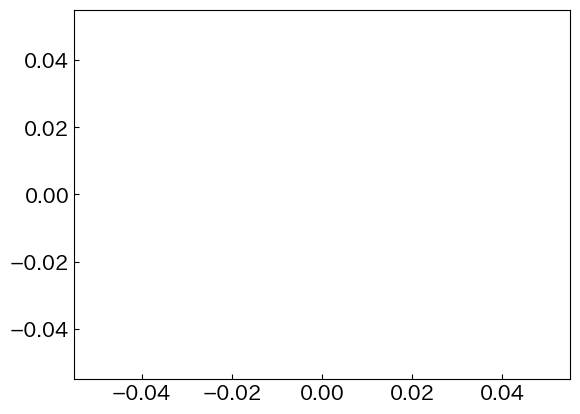

Unnamed: 0      0.000000
dec_min        39.956051
ra_min        305.571752
dec_max        39.980695
ra_max        305.606595
width_pix      39.000000
height_pix     39.000000
ra_center     305.589174
dec_center     39.968373
GLON           77.925676
GLAT            1.682483
GLON_min       77.907930
GLAT_min        1.686419
GLON_max       77.943421
GLAT_max        1.678551
Name: 65, dtype: float64
65
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

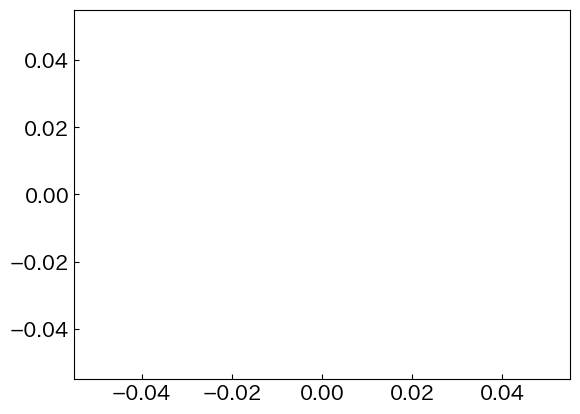

Unnamed: 0      0.000000
dec_min        41.521836
ra_min        309.325273
dec_max        41.592032
ra_max        309.413725
width_pix     101.000000
height_pix    104.000000
ra_center     309.369499
dec_center     41.556934
GLON           80.893616
GLAT            0.299214
GLON_min       80.845645
GLAT_min        0.304365
GLON_max       80.941578
GLAT_max        0.294102
Name: 66, dtype: float64
66
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

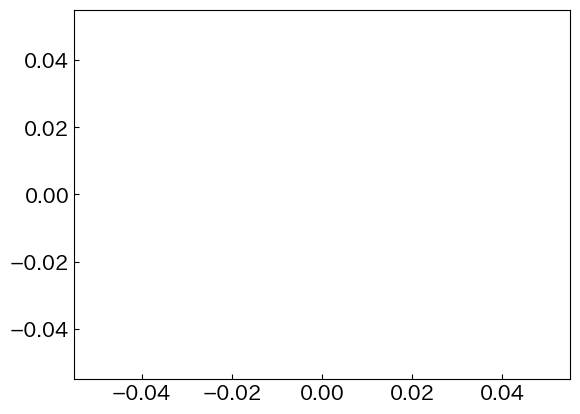

Unnamed: 0      0.000000
dec_min        41.194788
ra_min        308.799497
dec_max        41.227292
ra_max        308.840638
width_pix      46.000000
height_pix     49.000000
ra_center     308.820067
dec_center     41.211040
GLON           80.369211
GLAT            0.420003
GLON_min       80.346924
GLAT_min        0.422643
GLON_max       80.391497
GLAT_max        0.417370
Name: 67, dtype: float64
67
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

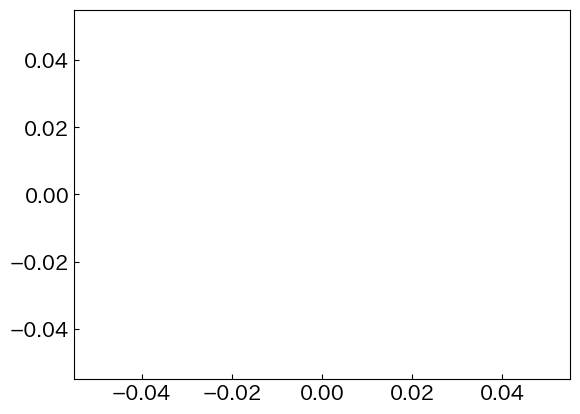

Unnamed: 0      0.000000
dec_min        41.123460
ra_min        306.301226
dec_max        41.187882
ra_max        306.387514
width_pix      95.000000
height_pix     98.000000
ra_center     306.344370
dec_center     41.155671
GLON           79.227885
GLAT            1.893914
GLON_min       79.182805
GLAT_min        1.901875
GLON_max       79.272958
GLAT_max        1.885989
Name: 68, dtype: float64
68
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

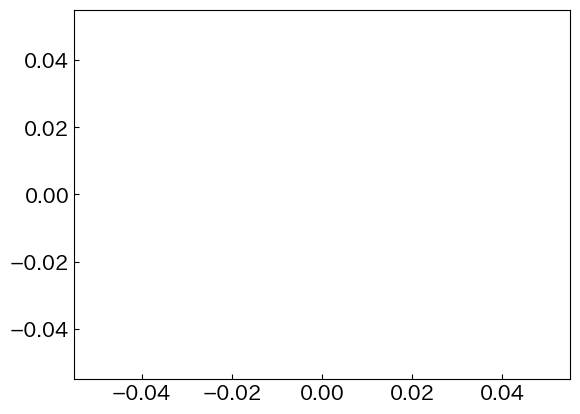

Unnamed: 0      0.000000
dec_min        40.005697
ra_min        306.823467
dec_max        40.067210
ra_max        306.907119
width_pix      95.000000
height_pix     93.000000
ra_center     306.865293
dec_center     40.036453
GLON           78.544878
GLAT            0.922893
GLON_min       78.501220
GLAT_min        0.931044
GLON_max       78.588531
GLAT_max        0.914774
Name: 69, dtype: float64
69
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

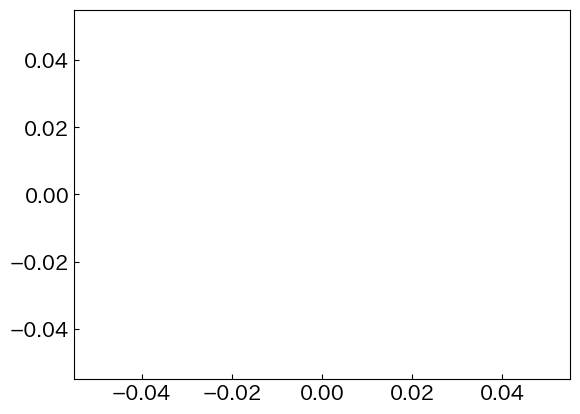

Unnamed: 0      0.000000
dec_min        39.686440
ra_min        309.419387
dec_max        39.716970
ra_max        309.456213
width_pix      44.000000
height_pix     45.000000
ra_center     309.437800
dec_center     39.701705
GLON           79.447805
GLAT           -0.864537
GLON_min       79.427076
GLAT_min       -0.862496
GLON_max       79.468533
GLAT_max       -0.866571
Name: 70, dtype: float64
70
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

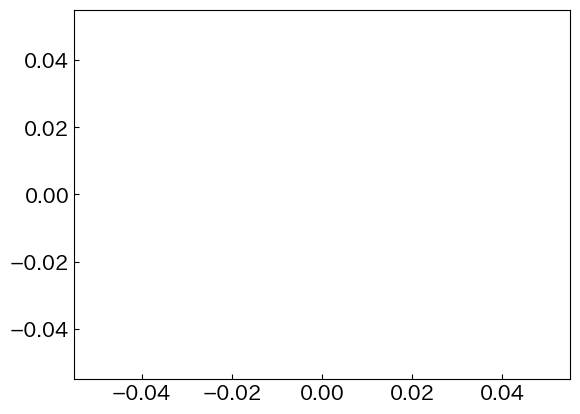

Unnamed: 0      0.000000
dec_min        41.388929
ra_min        305.162340
dec_max        41.417746
ra_max        305.202640
width_pix      44.000000
height_pix     45.000000
ra_center     305.182490
dec_center     41.403338
GLON           78.931706
GLAT            2.751903
GLON_min       78.911247
GLAT_min        2.756205
GLON_max       78.952163
GLAT_max        2.747607
Name: 71, dtype: float64
71
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

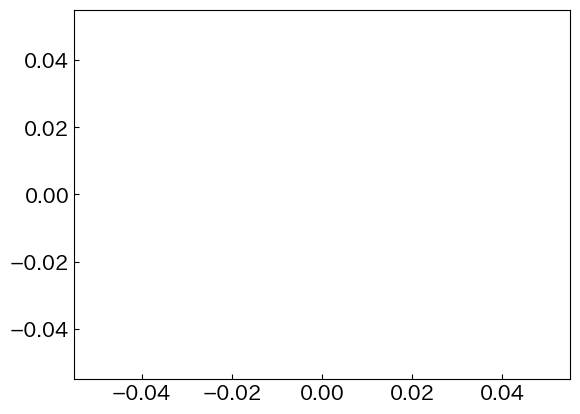

Unnamed: 0      0.000000
dec_min        42.580737
ra_min        309.643743
dec_max        42.604624
ra_max        309.674210
width_pix      34.000000
height_pix     36.000000
ra_center     309.658977
dec_center     42.592680
GLON           81.847748
GLAT            0.755994
GLON_min       81.831447
GLAT_min        0.757652
GLON_max       81.864049
GLAT_max        0.754340
Name: 72, dtype: float64
72
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

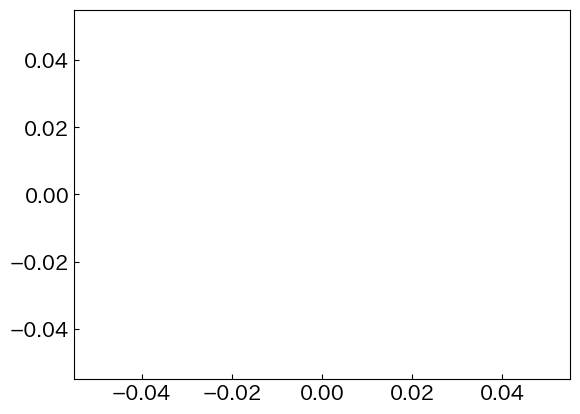

Unnamed: 0      0.000000
dec_min        40.202114
ra_min        305.540874
dec_max        40.269707
ra_max        305.628996
width_pix      99.000000
height_pix    104.000000
ra_center     305.584935
dec_center     40.235910
GLON           78.143650
GLAT            1.837786
GLON_min       78.096677
GLAT_min        1.846150
GLON_max       78.190617
GLAT_max        1.829458
Name: 73, dtype: float64
73
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

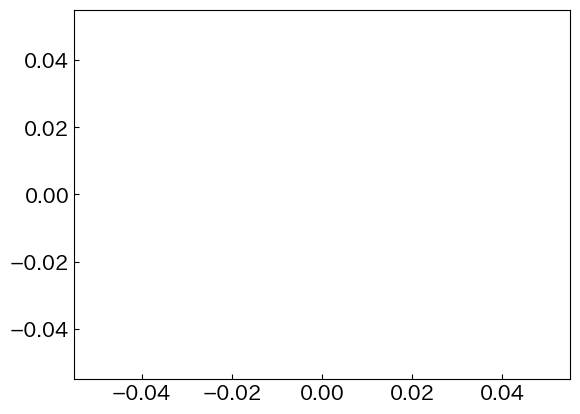

Unnamed: 0      0.000000
dec_min        39.838105
ra_min        309.394425
dec_max        39.879458
ra_max        309.447556
width_pix      62.000000
height_pix     61.000000
ra_center     309.420990
dec_center     39.858782
GLON           79.565044
GLAT           -0.759191
GLON_min       79.536239
GLAT_min       -0.755461
GLON_max       79.593846
GLAT_max       -0.762906
Name: 74, dtype: float64
74
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

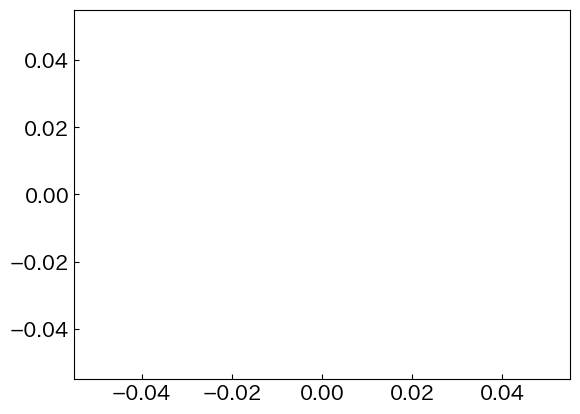

Unnamed: 0      0.000000
dec_min        42.262325
ra_min        309.294624
dec_max        42.291281
ra_max        309.332482
width_pix      42.000000
height_pix     43.000000
ra_center     309.313553
dec_center     42.276803
GLON           81.441956
GLAT            0.767504
GLON_min       81.421955
GLAT_min        0.769921
GLON_max       81.461955
GLAT_max        0.765094
Name: 75, dtype: float64
75
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

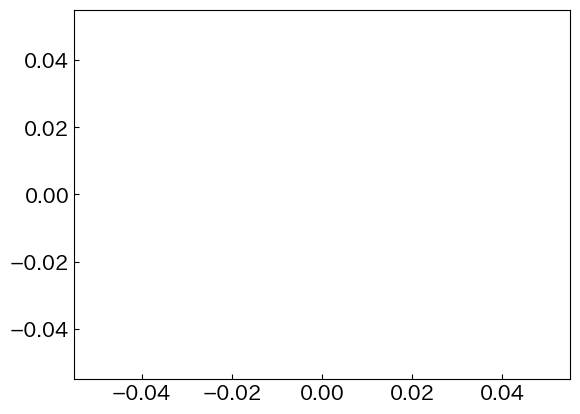

Unnamed: 0      0.000000
dec_min        41.954736
ra_min        309.778572
dec_max        42.023760
ra_max        309.871682
width_pix     106.000000
height_pix    101.000000
ra_center     309.825127
dec_center     41.989248
GLON           81.443440
GLAT            0.291467
GLON_min       81.394989
GLAT_min        0.297921
GLON_max       81.491883
GLAT_max        0.285054
Name: 76, dtype: float64
76
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

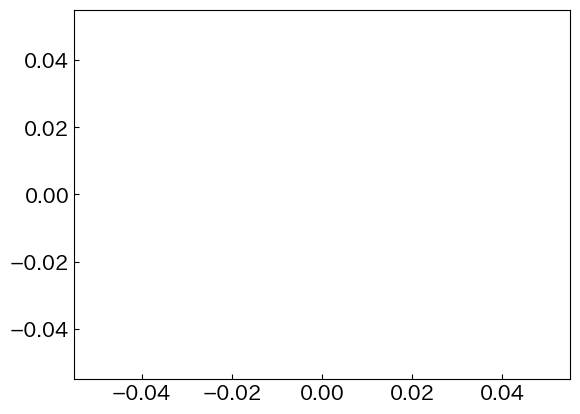

Unnamed: 0      0.000000
dec_min        41.206642
ra_min        308.759384
dec_max        41.237615
ra_max        308.798057
width_pix      44.000000
height_pix     46.000000
ra_center     308.778720
dec_center     41.222128
GLON           80.359438
GLAT            0.451543
GLON_min       80.338323
GLAT_min        0.453907
GLON_max       80.380552
GLAT_max        0.449186
Name: 77, dtype: float64
77
vaxis: [-39.875 -39.625 -39.375 -39.125 -38.875 -38.625 -38.375 -38.125 -37.875
 -37.625 -37.375 -37.125 -36.875 -36.625 -36.375 -36.125 -35.875 -35.625
 -35.375 -35.125 -34.875 -34.625 -34.375 -34.125 -33.875 -33.625 -33.375
 -33.125 -32.875 -32.625 -32.375 -32.125 -31.875 -31.625 -31.375 -31.125
 -30.875 -30.625 -30.375 -30.125 -29.875 -29.625 -29.375 -29.125 -28.875
 -28.625 -28.375 -28.125 -27.875 -27.625 -27.375 -27.125 -26.875 -26.625
 -26.375 -26.125 -25.875 -25.625 -25.375 -25.125 -24.875 -24.625 -24.375
 -24.125 -23.875 -23.625 -23.375 -23.125 -22.875 -22.625 -22.375 -22.125
 -21.8

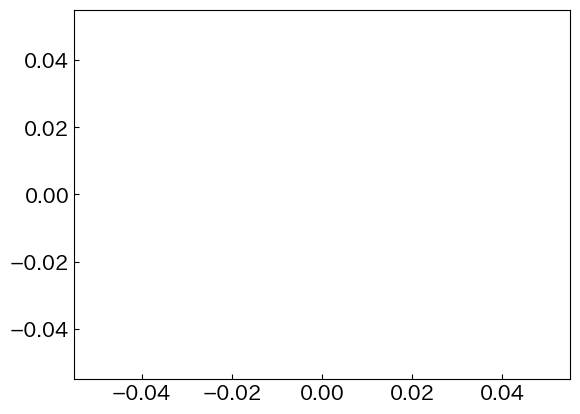

Generated: Cygnus-X_Bubble_Profile/Summary_Cygnus-X.png


In [17]:
# --- レイアウト設定 ---
bubbles_per_row = 2
rows_per_page = 100  # 1ページに表示する行数
bubbles_per_page = bubbles_per_row * rows_per_page
total_bubbles = len(cygnus_bubble_catalogue_selected)
# + len(MWP_selected)
num_pages = math.ceil(total_bubbles / bubbles_per_page)
    
# キャッシュ初期化
spitzer_path_cached = None

# ページごとのループ
for page in range(num_pages):
    start_idx = page * bubbles_per_page
    end_idx = min(start_idx + bubbles_per_page, total_bubbles)
    current_page_count = end_idx - start_idx

    # ページ内の必要行数を計算
    current_rows_in_page = math.ceil(current_page_count / bubbles_per_row)

    # ページ全体のFigure作成
    fig = plt.figure(figsize=(15*bubbles_per_row, 8 * current_rows_in_page))

    # サブフィギュアの作成
    subfigs_obj = fig.subfigures(current_rows_in_page, bubbles_per_row, wspace=0.1, hspace=0.1)

    # 【修正ポイント】戻り値が配列なら平坦化し、単一オブジェクトならリストに包む
    if isinstance(subfigs_obj, np.ndarray):
        subfigs = subfigs_obj.flatten()
    else:
        subfigs = [subfigs_obj]

    for p_idx, subfig in enumerate(subfigs):
        i_in_catalogue = start_idx + p_idx
        if i_in_catalogue >= total_bubbles:
            subfig.set_visible(False)
            continue

        each_catalogue = cygnus_bubble_catalogue_selected.iloc[i_in_catalogue]
        print(each_catalogue)
        i = each_catalogue.name # 元のインデックス
        print(i)
        
        # --- データ処理ロジック (省略なし) ---
        velocity_stats['total_bubble'] += 1

        bubble_info = {
            'region': region_name,
            'catalogue_index': i,
            'ra_center': each_catalogue['ra_center'],
            'dec_center': each_catalogue['dec_center'],
            'GLON':each_catalogue['GLON'],
            'GLAT':each_catalogue['GLAT'],
            'GLON_min':each_catalogue['GLON_min'],
            'GLAT_min':each_catalogue['GLAT_min'],
            'GLON_max':each_catalogue['GLON_max'],
            'GLAT_max':each_catalogue['GLAT_max'],
            'velocity_source': None,
            'v_peak': None,
            'fwhm_vel': None,
            'has_c18o_peak': False,
            'status': None
        }

        # Spitzerデータのロード（キャッシュを利用）
        current_spitzer_path = os.path.join("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/Spitzer/processed_fits/RGB/")
        if current_spitzer_path != spitzer_path_cached:
            spitzer_rfits, spitzer_gfits, spitzer_data, w_spitzer = load_spitzer_fits(current_spitzer_path)
            spitzer_path_cached = current_spitzer_path

        # スペクトルデータを抽出
        cut_data_12CO = extract_spectral(w_co, cygnus_cube_fits_12CO, each_catalogue)
        cut_data_13CO = extract_spectral(w_co, cygnus_cube_fits_13CO, each_catalogue)
        cut_data_C18O = extract_spectral(w_co, cygnus_cube_fits_C18O, each_catalogue)

        zeroing_cut_data_12CO = extract_spectral(w_co, Zeroing_cygnus_cube_fits_12CO, each_catalogue)
        zeroing_cut_data_13CO = extract_spectral(w_co, Zeroing_cygnus_cube_fits_13CO, each_catalogue)
        zeroing_cut_data_C18O = extract_spectral(w_co, Zeroing_cygnus_cube_fits_C18O, each_catalogue)

        # 平均スペクトルを計算
        mean_data_12CO = np.nanmean(cut_data_12CO, axis=(1, 2))
        mean_data_13CO = np.nanmean(cut_data_13CO, axis=(1, 2))
        mean_data_C18O = np.nanmean(cut_data_C18O, axis=(1, 2))


        print('vaxis:', vaxis, 'mean_data_12CO:', mean_data_12CO)
        plt.plot(vaxis, mean_data_12CO, "k", drawstyle='steps-mid')
        plt.show()

        # C18Oのピーク検証
        c18o_v_peak, c18o_t_peak, c18o_fwhm_vel, c18o_peak_channel = find_verified_peak(
            c18o_spec=mean_data_C18O,
            co12_spec=mean_data_12CO,
            co13_spec=mean_data_13CO,
            vaxis=vaxis, dv=dv
        )

        bubble_info['has_c18o_peak'] = c18o_v_peak is not None

        # [cite_start]カタログ（Beaumont & Williams 2014等）から速度情報を検索
        catalog_v_peak, catalog_fwhm_vel, catalog_info = find_velocity_from_catalog(
            each_catalogue['GLON'], 
            each_catalogue['GLAT'], 
            bub_velocity_table,
            search_radius=(each_catalogue['GLON_max'] - each_catalogue['GLON_min'])/2
        )

        if catalog_v_peak is not None:
            used_tracer = f"Catalog (Row {catalog_info['catalog_index']})"
            v_peak = catalog_v_peak
            fwhm_vel = catalog_fwhm_vel
            t_peak = np.nan
            peak_channel = np.argmin(np.abs(vaxis - v_peak))
            
            if bubble_info['has_c18o_peak'] and abs(c18o_v_peak - catalog_v_peak) <= 10.0:
                velocity_stats['catalogue_vel_with_c18o'] += 1
            else:
                bubble_info['has_c18o_peak'] = False 
            
            velocity_stats['catalogue_vel_bubble'] += 1
            bubble_info.update({'velocity_source': 'Catalog', 'v_peak': v_peak, 'fwhm_vel': fwhm_vel, 'status': 'Success'})
            
        elif c18o_v_peak is not None:
            used_tracer = "C18O (verified)"
            v_peak, t_peak, fwhm_vel, peak_channel = c18o_v_peak, c18o_t_peak, c18o_fwhm_vel, c18o_peak_channel
            velocity_stats['c18o_vel_bubble'] += 1
            bubble_info.update({'velocity_source': 'C18O', 'v_peak': v_peak, 'fwhm_vel': fwhm_vel, 'status': 'Success'})
            
        else:
            used_tracer = "13CO"
            v_peak, t_peak, fwhm_vel, peak_channel = _detect_and_characterize_peak(
                mean_data_13CO, vaxis, dv, height_factor=5.0, prominence_factor=3.0
            )
            if v_peak is not None:
                velocity_stats['co13_vel_bubble'] += 1
                bubble_info.update({'velocity_source': '13CO', 'v_peak': v_peak, 'fwhm_vel': fwhm_vel, 'status': 'Success'})
            else:
                velocity_stats['no_vel_bubble'] += 1
                bubble_info.update({'velocity_source': 'None', 'status': 'No velocity detected'})
                subfig.text(0.5, 0.5, f"No velocity detected\nIdx: {i}", ha='center', va='center', fontsize=12)
                bubble_details.append(bubble_info)
                continue

        # 速度範囲の設定
        range_start_vel = v_peak - fwhm_vel * 2.5
        range_end_vel = v_peak + fwhm_vel * 2.5
        range_indices = np.where((vaxis >= range_start_vel) & (vaxis <= range_end_vel))[0]

        # Momentマップ作成 (FUGINデータを使用)
        datadict_12CO = make_momont012_map(cygnus_cube_fits_12CO, w_co, zeroing_cut_data_12CO[range_indices], vaxis[range_indices], v_center=v_peak)
        datadict_13CO = make_momont012_map(cygnus_cube_fits_13CO, astropy.wcs.WCS(cygnus_cube_fits_13CO.header), zeroing_cut_data_13CO[range_indices], vaxis[range_indices], v_center=v_peak)
        datadict_C18O = make_momont012_map(cygnus_cube_fits_C18O, astropy.wcs.WCS(cygnus_cube_fits_C18O.header), zeroing_cut_data_C18O[range_indices], vaxis[range_indices], v_center=v_peak)

        # Spitzer画像の準備
        new_hdu_list_r, new_hdu_list_g = make_spitzer_fits(spitzer_rfits, spitzer_gfits, w_spitzer, spitzer_data, each_catalogue)
        if new_hdu_list_r == 0:
            velocity_stats['spitzer_error_bubble'] += 1
            bubble_info['status'] = 'Spitzer error'
            subfig.text(0.5, 0.5, f"Spitzer Error\nIdx: {i}", ha='center', va='center', fontsize=12)
            bubble_details.append(bubble_info)
            continue
            
        cut_spitzer = np.concatenate([
            new_hdu_list_r[0].data[:,:,None],
            new_hdu_list_g[0].data[:,:,None],
            np.zeros(new_hdu_list_r[0].data.shape)[:,:,None]
        ], axis=2)

        # --- プロット処理 ---
        v_peak_str = f"{v_peak:.1f}" if v_peak is not None else "N/A"
        c18o_v_peak_str = f"{c18o_v_peak:.1f}" if c18o_v_peak is not None else "N/A"

        if "Catalog" in used_tracer:
            title = (f"Peak from Hou et al. 2013, "
                     f"V_HII={v_peak_str} km/s, C18O peak={c18o_v_peak_str} km/s")
        else:
            title = (f"Catalogue: {i}, Bubble: {each_catalogue.get('name', 'N/A')}, "
                     f"Peak from {used_tracer} at V_lsr={v_peak_str} km/s")

        # subfigにタイトルを設定
        subfig.suptitle(title, fontsize=20, fontweight='bold', y=0.98)
        
        gs = GridSpec(3, 7, figure=subfig, width_ratios=[1, 1, 1, 1, 1, 1, 2], 
                      wspace=0.8, hspace=0.3, left=0.05, right=0.95, top=0.90, bottom=0.08)

        # 1. Spitzer赤外線画像
        ax = subfig.add_subplot(gs[:3, :3], projection=astropy.wcs.WCS(new_hdu_list_r[0].header))
        ax.imshow(cut_spitzer)
        ax.tick_params(labelsize=8)
        ax.set_xlabel('Galactic Longitude', fontsize=15)
        ax.set_ylabel('Galactic Latitude', fontsize=15)

        # 2. スペクトル (12CO, 13CO, C18O)
        spectral_data_list = [("12CO", mean_data_12CO), ("13CO", mean_data_13CO), ("C18O", mean_data_C18O)]
        for idx, (label, spec_data) in enumerate(spectral_data_list):
            ax = subfig.add_subplot(gs[idx, 3:6])
            ax.plot(vaxis, spec_data, "k", label=label, drawstyle='steps-mid')
            if len(range_indices) > 0:
                ax.plot(vaxis[range_indices], spec_data[range_indices], "o", color='red', markersize=2)
                ax.axvspan(range_start_vel, range_end_vel, alpha=0.2, color='red')
    
            ax.axvline(v_peak, color='blue', ls='--', lw=1, label=f'Peak: {v_peak_str} km/s')
            if bubble_info['has_c18o_peak'] and idx == 2:
                ax.axvline(c18o_v_peak, color='green', ls=':', lw=2, label=f'C18O peak: {c18o_v_peak_str} km/s')
    
            ax.set_xlim([-80, 80])
            ax.tick_params(axis='both', labelsize=12)
            ax.set_title(label, fontsize=15)
            ax.set_ylabel("Mean Tmb [K]", fontsize=12)
            ax.legend(fontsize=10, loc='upper right')

        # 3. 積分強度マップ (Moment 0)
        moms = [datadict_12CO, datadict_13CO, datadict_C18O]
        for idx, mdata in enumerate(moms):
            ax = subfig.add_subplot(gs[idx, 6:7])
            mdata = mdata['moment0']
            ax.imshow(mdata, origin='lower', interpolation='none', cmap='viridis')

            # コントア作成
            x_width = mdata.shape[1]
            y_width = mdata.shape[0]
            x = np.linspace(0, x_width, x_width)
            y = np.linspace(0, y_width, y_width)
            X, Y = np.meshgrid(x, y)
            sig1 = 1 / (2 * (np.log(2)) ** 0.5)

            # 修正：resize(conv(...)) の結果が正しく渡るように
            try:
                spitzer_contour_data = resize(conv(int(x_width), sig1, cut_spitzer), (int(y_width), int(x_width)))[:,:,1]
                contour = ax.contour(X, Y, spitzer_contour_data, levels=[0.1, 0.3, 0.5], colors=['w'], linewidths=3)
                ax.clabel(contour, inline=True, fontsize=12)
            except Exception as e:
                print(f"Contour error at index {i}: {e}")

            r_pix = x_width/4
            center_pix = x_width/2
            tick_pos = center_pix + np.array([-1, 0, 1]) * r_pix
            ax.set_xticks(tick_pos); ax.set_xticklabels(['-R', '0', 'R'])
            ax.set_yticks(tick_pos); ax.set_yticklabels(['-R', '0', 'R'])
            ax.set_title(['12CO', '13CO', 'C18O'][idx] + ' Moment 0', fontsize=15)

        bubble_details.append(bubble_info)

    # ページ保存
    # dir_name = f"FUGIN_Bubble_Profile/{region_name}"
    # os.makedirs(dir_name, exist_ok=True)

    out_name = f"Cygnus-X_Bubble_Profile/Summary_Cygnus-X.png"

    # plt.savefig(out_name, dpi=72, bbox_inches='tight')
    # plt.close(fig)
    plt.show()
    print(f"Generated: {out_name}")